<a id="big_data_system_testing_data_lake_goto_transactions"></a>
# Big Data System Testing — Data Lake (GoTo Transactions)
**Nama:** Josia Given Santoso  
**NIM:** 36230035  
**Mata Kuliah:** DSB17 — Big Data Management and Processing  
**Kelas:** 6PDS1  
**Dosen Pengampu:** Eko Wahyu Prasetyo, S.T., M.Eng  

---

<h3><b>Table of Contents</b></h3>

- [Big Data System Testing — Data Lake (GoTo Transactions)](#big_data_system_testing_data_lake_goto_transactions)<br>
&nbsp;&nbsp;&nbsp;&nbsp;- [Soal 1 — Arsitektur Data Lake](#soal_1_arsitektur_data_lake)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [1.1 Load Dataset](#11_load_dataset)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [1.2 Diagram Alur Zona](#12_diagram_alur_zona)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [1.3 Tabel Fungsi Zona](#13_tabel_fungsi_zona)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [1.4 Uji Immutability RAW Zone](#14_uji_immutability_raw_zone)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [1.5 Mengapa Data Tidak Boleh Langsung ke Refined](#15_mengapa_data_tidak_boleh_langsung_ke_refined)<br>
&nbsp;&nbsp;&nbsp;&nbsp;- [Soal 2 — Pengujian Zona](#soal_2_pengujian_zona)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [2A. Ingestion & Transition Zone](#2a_ingestion_transition_zone)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [File Batch Rusak](#file_batch_rusak)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Deteksi Event Duplikat](#deteksi_event_duplikat)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Schema Drift](#schema_drift)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [2B. RAW Zone](#2b_raw_zone)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Checksum & Immutability](#checksum_immutability)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Penyimpanan Historis](#penyimpanan_historis)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [2C. Trusted Zone](#2c_trusted_zone)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Validasi Tipe Data](#validasi_tipe_data)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Duplikasi](#duplikasi)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Missing Value](#missing_value)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Nilai Tidak Masuk Akal](#nilai_tidak_masuk_akal)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [2D. Refined Zone](#2d_refined_zone)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Konsistensi Data Analitik](#konsistensi_data_analitik)<br>
&nbsp;&nbsp;&nbsp;&nbsp;- [Soal 3 — Pengujian Kualitas Data](#soal_3_pengujian_kualitas_data)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [3.1 Load Data & Inisialisasi Flag](#31_load_data_inisialisasi_flag)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [3.2 DQ-01: Duplikasi event_id](#32_dq_01_duplikasi_event_id)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [3.3 DQ-02: Amount Negatif / Nol](#33_dq_02_amount_negatif_nol)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [3.4 DQ-03: Missing Timestamp](#34_dq_03_missing_timestamp)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [3.5 DQ-04: Outlier Ekstrem](#35_dq_04_outlier_ekstrem)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [3.6 DQ-05: Konsistensi fraud_flag](#36_dq_05_konsistensi_fraud_flag)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [3.7 Ringkasan Trusted vs Rejected](#37_ringkasan_trusted_vs_rejected)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [3.8 Dampak Data Kotor di Refined](#38_dampak_data_kotor_di_refined)<br>
&nbsp;&nbsp;&nbsp;&nbsp;- [Soal 4 — Pemrosesan dengan Apache Spark](#soal_4_pemrosesan_dengan_apache_spark)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [4.1 Inisialisasi SparkSession](#41_inisialisasi_sparksession)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [4.2 Load & Partisi](#42_load_partisi)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [4.3 Agregasi Metrik](#43_agregasi_metrik)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Total Amount per Hari](#total_amount_per_hari)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Jumlah Transaksi per User](#jumlah_transaksi_per_user)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Persentase Fraud per Service Type](#persentase_fraud_per_service_type)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Rata-rata Amount per Payment Method](#rata_rata_amount_per_payment_method)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [4.4 Fault Tolerance](#44_fault_tolerance)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [4.5 Spark vs MapReduce](#45_spark_vs_mapreduce)<br>
&nbsp;&nbsp;&nbsp;&nbsp;- [Soal 5 — Keamanan, Lineage & Monitoring](#soal_5_keamanan_lineage_monitoring)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [5.1 Access Control](#51_access_control)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [5.2 Data Masking](#52_data_masking)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [5.3 Data Lineage](#53_data_lineage)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [5.4 Monitoring Metrics](#54_monitoring_metrics)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Job Failure Simulation](#job_failure_simulation)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Latency per Batch](#latency_per_batch)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Storage Growth](#storage_growth)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Alert Rules](#alert_rules)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- [Dashboard Monitoring](#dashboard_monitoring)<br>

---
<a id="soal_1_arsitektur_data_lake"></a>
## Soal 1 — Arsitektur Data Lake
---

Preview dataset GoTo Transactions dan gambaran arsitektur zona Data Lake.

<a id="11_load_dataset"></a>
### 1.1 Load Dataset
Load file parquet dari folder datasets.

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns
import hashlib

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [140]:
df = pd.read_parquet('../datasets/goto_transactions.parquet')
tp = pd.read_parquet('../datasets/test_plan.parquet')

print(f"Transactions shape: {df.shape}")
print(f"Test plan shape:    {tp.shape}")
display(df.head(10))

Transactions shape: (50000, 11)
Test plan shape:    (7, 4)


,event_id,user_id,service_type,merchant_id,amount,discount,payment_method,distance_km,rating,fraud_flag,ts
0,gtx_0,71190,gosend,113,45587.0,0,cash,1.388800,2,0,2024-01-23 18:00:00
1,gtx_1,42212,gocar,618,120816.0,10000,gopay,5.029131,4,0,2024-01-27 12:00:00
2,gtx_2,79676,tokopedia,14926,35435.0,5000,gopay,1.530948,5,0,2024-01-18 19:00:00
3,gtx_3,15559,tokopedia,13375,76651.0,0,gopay,7.009498,5,0,2024-01-13 17:00:00
4,gtx_4,66298,tokopedia,16504,91778.0,5000,cash,4.708059,2,0,2024-01-01 06:00:00
5,gtx_5,93250,goride,16625,69579.0,0,paylater,3.256653,5,0,2024-01-19 22:00:00
6,gtx_6,3380,gofood,16142,83992.0,5000,gopay,2.900140,5,0,2024-01-28 18:00:00
7,gtx_7,43262,gocar,14406,145967.0,0,gopay,3.873607,4,0,2024-01-05 18:00:00
8,gtx_8,4088,gofood,12734,80398.0,5000,card,9.060113,3,0,2024-01-08 06:00:00
9,gtx_9,78834,goride,7463,23987.0,20000,cash,6.225025,4,0,2024-01-16 12:00:00


In [141]:
print("--- Column Types ---")
display(df.dtypes.to_frame('dtype'))

print("\n--- Descriptive Statistics ---")
display(df.describe())

--- Column Types ---


,dtype
event_id,str
user_id,int64
service_type,str
merchant_id,int64
amount,float64
discount,int32
payment_method,str
distance_km,float64
rating,int64
fraud_flag,int32



--- Descriptive Statistics ---


,user_id,merchant_id,amount,discount,distance_km,rating,fraud_flag,ts
count,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000
mean,49929.809760,10018.256660,7.400760e+04,4997.800000,3.988865,3.000980,0.020000,2024-01-16 02:05:27.744000
min,3.000000,1.000000,5.389000e+03,0.000000,0.013481,1.000000,0.000000,2024-01-01 00:00:00
25%,25040.500000,4999.000000,4.313775e+04,0.000000,1.920736,2.000000,0.000000,2024-01-08 14:00:00
50%,49796.500000,10031.000000,6.070200e+04,0.000000,3.360298,3.000000,0.000000,2024-01-16 03:00:00
75%,74821.000000,15037.000000,8.626325e+04,10000.000000,5.376247,4.000000,0.000000,2024-01-23 14:00:00
max,99994.000000,19999.000000,1.675978e+06,20000.000000,24.788914,5.000000,1.000000,2024-01-30 23:00:00
std,28751.449142,5772.561262,6.365724e+04,6327.779703,2.807359,1.414772,0.140001,NaN


In [142]:
print("--- Test Plan ---")
display(tp)

--- Test Plan ---


,Area,TestCase,Method,Expected
0,Ingestion-Streaming,Peak-hour burst resilience,Simulate 20x GoFood traffic during lunch/dinner,"No loss, latency SLA maintained"
1,Ingestion-Streaming,Late event handling,Inject delayed transactions (1–24h),Correct backfill without duplication
2,Ingestion-Batch,Schema evolution,Add new column mid-batch,Pipeline adapts or isolates invalid batch
3,DataQuality,Heavy-tail transaction check,Validate extreme GMV outliers,Flagged but not pipeline-breaking
4,DataQuality,Negative net prevention,Check amount >= discount,No negative revenue
5,RiskDetection,Burst fraud cluster,Same user high-frequency transactions,Velocity anomaly detected
6,Performance,Columnar efficiency,Parquet vs CSV aggregation benchmark,Parquet significantly faster


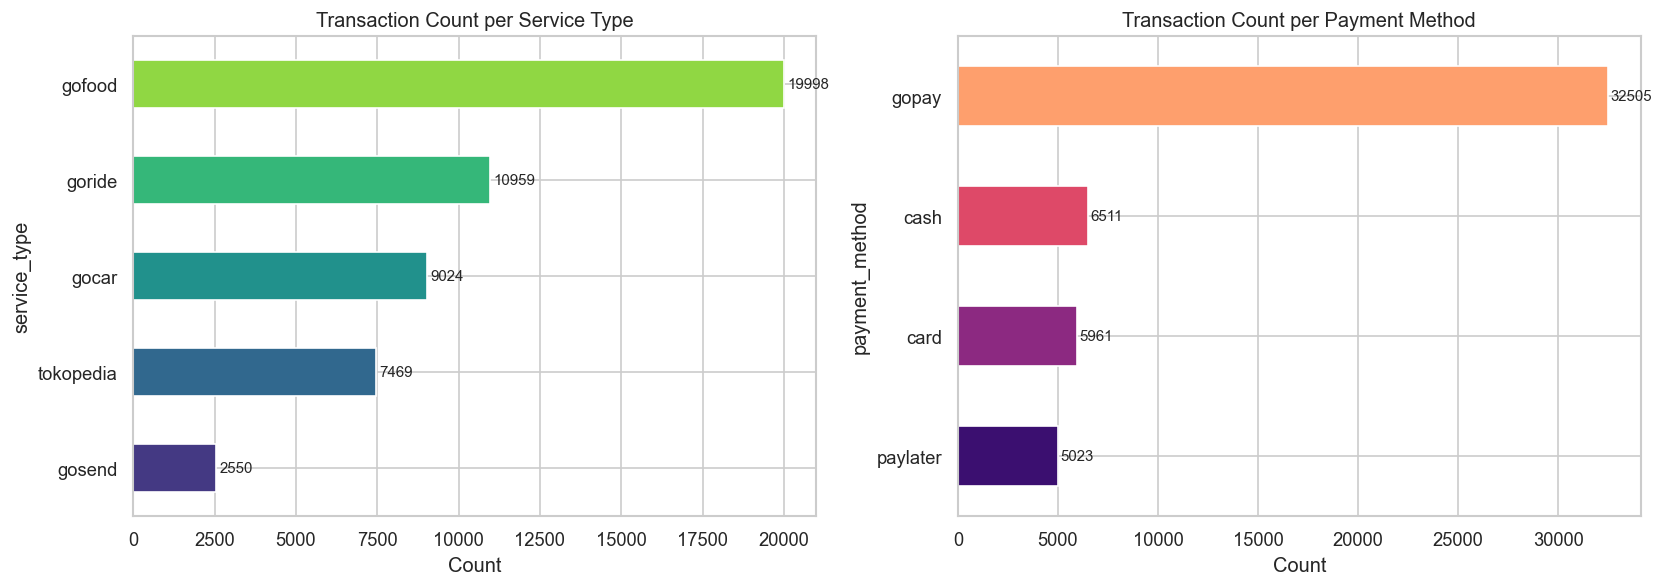

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# transaction count per service_type
svc_counts = df['service_type'].value_counts().sort_values(ascending=True)
colors_svc = sns.color_palette('viridis', len(svc_counts))
svc_counts.plot.barh(ax=axes[0], color=colors_svc)
axes[0].set_title('Transaction Count per Service Type')
axes[0].set_xlabel('Count')
for i, v in enumerate(svc_counts.values):
    axes[0].text(v + 100, i, str(v), va='center', fontsize=9)

# transaction count per payment_method
pay_counts = df['payment_method'].value_counts().sort_values(ascending=True)
colors_pay = sns.color_palette('magma', len(pay_counts))
pay_counts.plot.barh(ax=axes[1], color=colors_pay)
axes[1].set_title('Transaction Count per Payment Method')
axes[1].set_xlabel('Count')
for i, v in enumerate(pay_counts.values):
    axes[1].text(v + 100, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

<a id="12_diagram_alur_zona"></a>
### 1.2 Diagram Alur Zona
Visualisasi alur data dari sumber hingga Refined Zone.

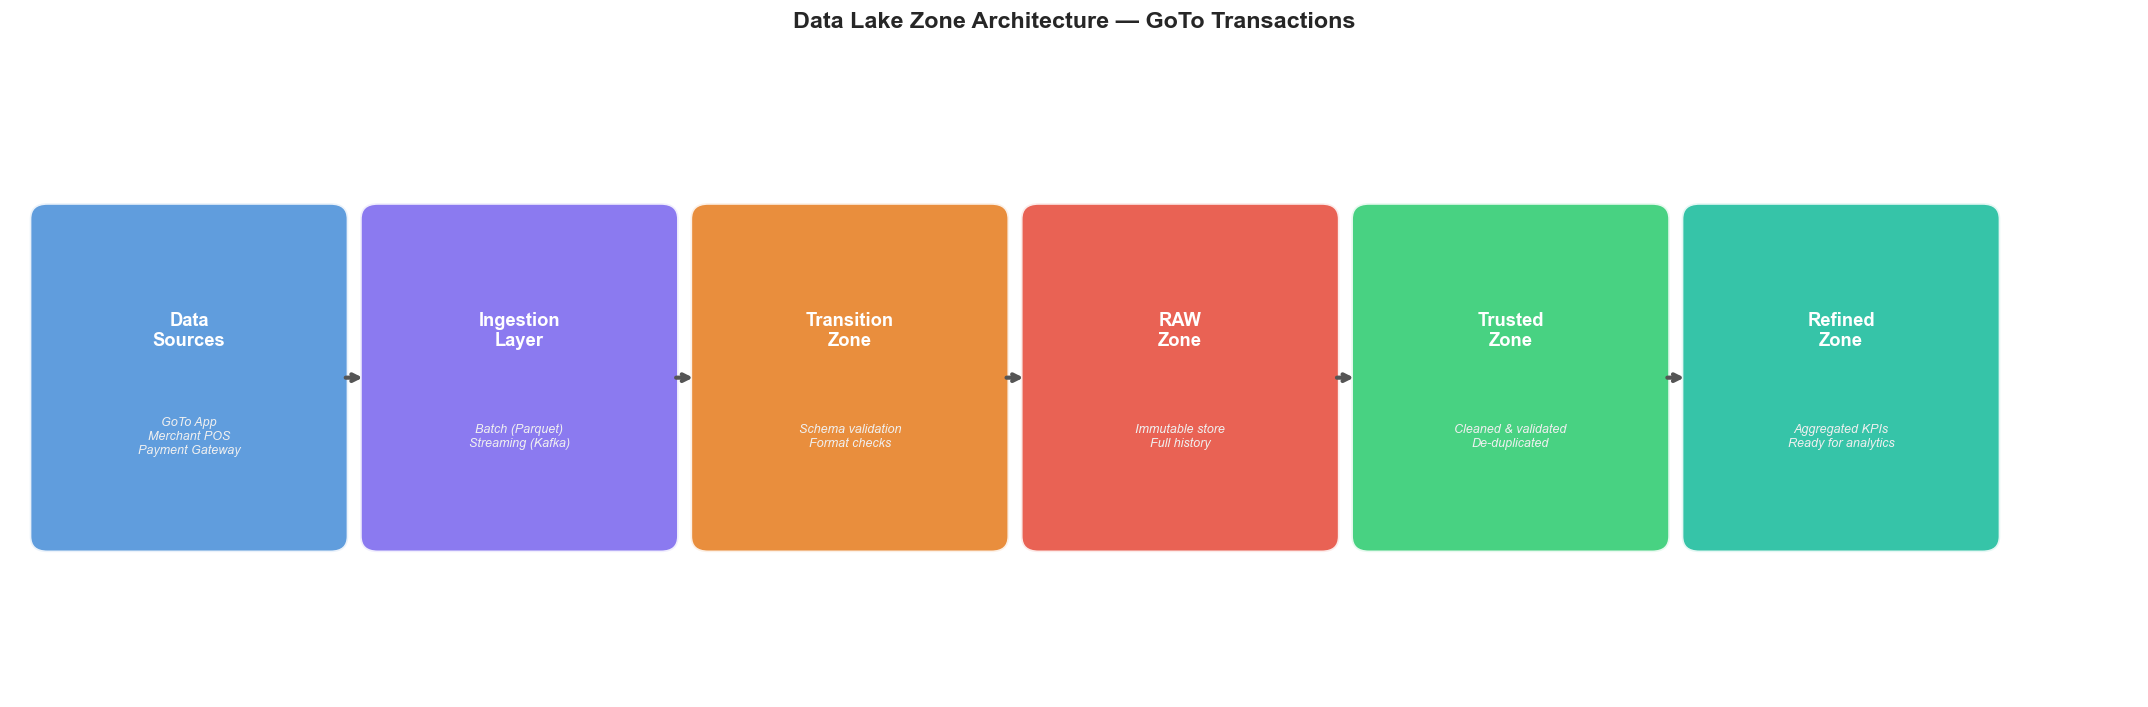

In [144]:
fig, ax = plt.subplots(figsize=(18, 6))
ax.set_xlim(0, 18)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title('Data Lake Zone Architecture — GoTo Transactions', fontsize=14, fontweight='bold', pad=20)

zones = [
    {'name': 'Data\nSources',     'x': 0.3,  'color': '#4A90D9'},
    {'name': 'Ingestion\nLayer',   'x': 3.1,  'color': '#7B68EE'},
    {'name': 'Transition\nZone',   'x': 5.9,  'color': '#E67E22'},
    {'name': 'RAW\nZone',          'x': 8.7,  'color': '#E74C3C'},
    {'name': 'Trusted\nZone',      'x': 11.5, 'color': '#2ECC71'},
    {'name': 'Refined\nZone',      'x': 14.3, 'color': '#1ABC9C'},
]

subtexts = [
    'GoTo App\nMerchant POS\nPayment Gateway',
    'Batch (Parquet)\nStreaming (Kafka)',
    'Schema validation\nFormat checks',
    'Immutable store\nFull history',
    'Cleaned & validated\nDe-duplicated',
    'Aggregated KPIs\nReady for analytics',
]

box_w, box_h = 2.4, 3.0
y_center = 3.0

for i, z in enumerate(zones):
    rect = FancyBboxPatch(
        (z['x'], y_center - box_h / 2), box_w, box_h,
        boxstyle='round,pad=0.15', facecolor=z['color'],
        edgecolor='white', linewidth=2, alpha=0.88
    )
    ax.add_patch(rect)
    ax.text(z['x'] + box_w / 2, y_center + 0.45, z['name'],
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    ax.text(z['x'] + box_w / 2, y_center - 0.55, subtexts[i],
            ha='center', va='center', fontsize=7.5, color='#F0F0F0', style='italic')

    # draw arrow to next zone
    if i < len(zones) - 1:
        ax.annotate(
            '', xy=(zones[i + 1]['x'] - 0.1, y_center),
            xytext=(z['x'] + box_w + 0.1, y_center),
            arrowprops=dict(arrowstyle='->', color='#555', lw=2.5)
        )

plt.tight_layout()
plt.show()

<a id="13_tabel_fungsi_zona"></a>
### 1.3 Tabel Fungsi Zona
Ringkasan fungsi dan aturan utama tiap zona.

In [145]:
zone_summary = pd.DataFrame({
    'Zone': [
        'Data Sources',
        'Ingestion Layer',
        'Transition Zone',
        'RAW Zone',
        'Trusted Zone',
        'Refined Zone'
    ],
    'Function': [
        'Origin of transactional data (GoTo App, Merchant POS, Payment Gateway)',
        'Handles batch (Parquet) and streaming (Kafka) ingestion pipelines',
        'Intermediate staging for schema validation, format conversion, quarantine',
        'Immutable long-term store of raw data in original form, append-only',
        'Cleaned, validated, deduplicated data ready for analytical queries',
        'Pre-aggregated KPIs, dimensional models, and analytical-ready datasets'
    ],
    'Key_Rule': [
        'Must emit data in supported formats (CSV, JSON, Parquet)',
        'Must handle schema drift, late arrivals, and backpressure',
        'Reject or quarantine invalid batches; never pass bad data downstream',
        'NEVER modify or delete — write-once, read-many (WORM)',
        'All records must pass data quality checks before landing here',
        'Only trusted records; optimized for read-heavy analytical workloads'
    ]
})

display(zone_summary.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2C3E50'), ('color', 'white'), ('text-align', 'center')]}
]))

,Zone,Function,Key_Rule
0,Data Sources,"Origin of transactional data (GoTo App, Merchant POS, Payment Gateway)","Must emit data in supported formats (CSV, JSON, Parquet)"
1,Ingestion Layer,Handles batch (Parquet) and streaming (Kafka) ingestion pipelines,"Must handle schema drift, late arrivals, and backpressure"
2,Transition Zone,"Intermediate staging for schema validation, format conversion, quarantine",Reject or quarantine invalid batches; never pass bad data downstream
3,RAW Zone,"Immutable long-term store of raw data in original form, append-only","NEVER modify or delete — write-once, read-many (WORM)"
4,Trusted Zone,"Cleaned, validated, deduplicated data ready for analytical queries",All records must pass data quality checks before landing here
5,Refined Zone,"Pre-aggregated KPIs, dimensional models, and analytical-ready datasets",Only trusted records; optimized for read-heavy analytical workloads


<a id="14_uji_immutability_raw_zone"></a>
### 1.4 Uji Immutability RAW Zone
Membuktikan data RAW tidak berubah setelah proses baca.

In [146]:
# compute SHA-256 on raw file bytes
with open('../datasets/goto_transactions.parquet', 'rb') as f:
    raw_file_bytes = f.read()
raw_checksum = hashlib.sha256(raw_file_bytes).hexdigest()
print(f"RAW Zone checksum (SHA-256): {raw_checksum}")

# simulate an attempted modification on a COPY
modified_df = df.copy()
modified_df.loc[0, 'amount'] = 9999999.99
modified_df.loc[1, 'service_type'] = 'TAMPERED'

# re-read original file and verify checksum unchanged
with open('../datasets/goto_transactions.parquet', 'rb') as f:
    raw_file_bytes_after = f.read()
recheck_checksum = hashlib.sha256(raw_file_bytes_after).hexdigest()

print(f"Checksum after processing:  {recheck_checksum}")
print(f"\nChecksums match: {raw_checksum == recheck_checksum}")

assert raw_checksum == recheck_checksum, "FAIL: original was mutated!"
print("\nImmutability check PASSED — original data remains unchanged.")

RAW Zone checksum (SHA-256): 83b26ce47c19e2e8128f9756ecbabc16e3257f93582b0fd3eb57d70c27ec9312
Checksum after processing:  83b26ce47c19e2e8128f9756ecbabc16e3257f93582b0fd3eb57d70c27ec9312

Checksums match: True

Immutability check PASSED — original data remains unchanged.


<a id="15_mengapa_data_tidak_boleh_langsung_ke_refined"></a>
### 1.5 Mengapa Data Tidak Boleh Langsung ke Refined
Contoh konkret data kotor yang berbahaya jika langsung masuk Refined.

In [147]:
# outlier amounts exceeding 10M IDR
outlier_mask = df['amount'] > 10_000_000
outlier_df = df[outlier_mask]
print(f"Records with amount > 10,000,000 IDR: {len(outlier_df)}")
display(outlier_df.head(10))

Records with amount > 10,000,000 IDR: 0


,event_id,user_id,service_type,merchant_id,amount,discount,payment_method,distance_km,rating,fraud_flag,ts


In [148]:
# missing values in raw data
null_counts = df.isnull().sum()
print("--- Missing Values in Raw Data ---")
display(null_counts.to_frame('null_count').query('null_count > 0') if null_counts.sum() > 0
        else pd.DataFrame({'null_count': [0]}, index=['(no nulls found)']))

print(f"\nTotal nulls across all columns: {null_counts.sum()}")

--- Missing Values in Raw Data ---


,null_count
(no nulls found),0



Total nulls across all columns: 0


In [149]:
# potential duplicates
dup_mask = df.duplicated(subset=['event_id'], keep=False)
dup_count = dup_mask.sum()
print(f"Duplicate event_id records: {dup_count}")
if dup_count > 0:
    display(df[dup_mask].head(10))

Duplicate event_id records: 0


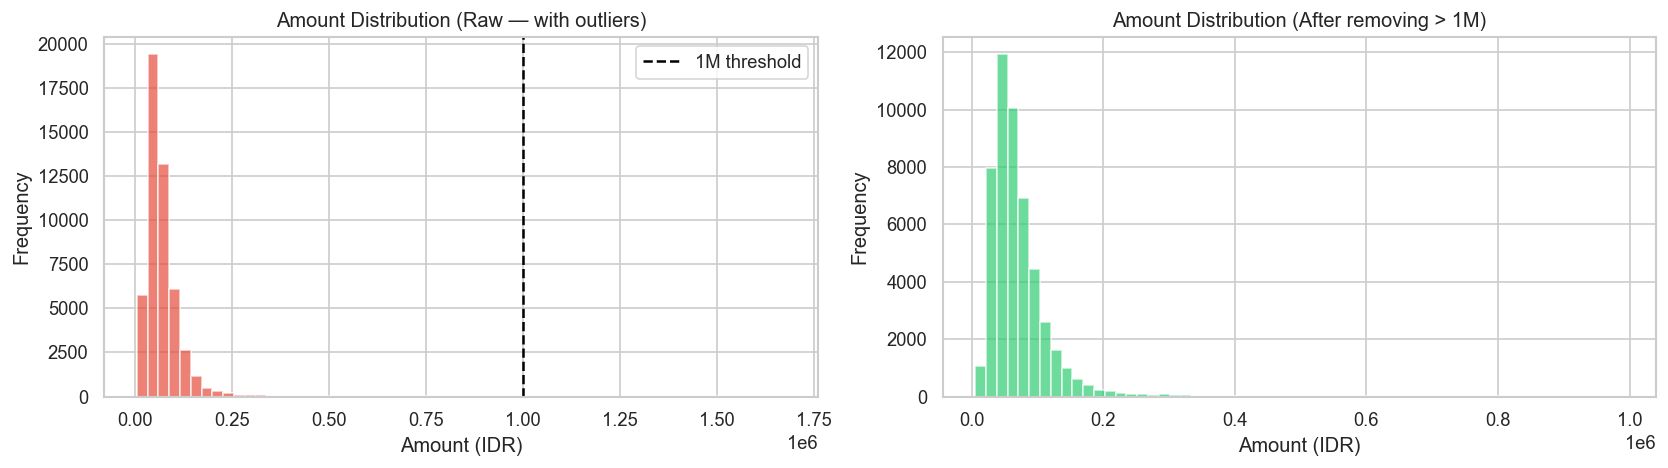


 Without validation, outliers and duplicates flow into Refined Zone,
   distorting aggregations and making analytics unreliable.


In [150]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['amount'], bins=60, color='#E74C3C', alpha=0.7, edgecolor='white')
axes[0].axvline(1_000_000, color='black', linestyle='--', linewidth=1.5, label='1M threshold')
axes[0].set_title('Amount Distribution (Raw — with outliers)')
axes[0].set_xlabel('Amount (IDR)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

clean = df[df['amount'] <= 1_000_000]['amount']
axes[1].hist(clean, bins=60, color='#2ECC71', alpha=0.7, edgecolor='white')
axes[1].set_title('Amount Distribution (After removing > 1M)')
axes[1].set_xlabel('Amount (IDR)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\n Without validation, outliers and duplicates flow into Refined Zone,")
print("   distorting aggregations and making analytics unreliable.")

---
<a id="soal_2_pengujian_zona"></a>
## Soal 2 — Pengujian Zona
---

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
import time
from collections import OrderedDict

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

EXPECTED_SCHEMA = OrderedDict({
    'event_id': 'object',
    'user_id': 'int64',
    'service_type': 'object',
    'merchant_id': 'int64',
    'amount': 'float64',
    'discount': 'int32',
    'payment_method': 'object',
    'distance_km': 'float64',
    'rating': 'int64',
    'fraud_flag': 'int32',
    'ts': 'datetime64[ns]'
})

REQUIRED_COLUMNS = list(EXPECTED_SCHEMA.keys())

<a id="2a_ingestion_transition_zone"></a>
### 2A. Ingestion & Transition Zone

<a id="file_batch_rusak"></a>
#### File Batch Rusak
Simulasi batch file rusak dengan menghapus kolom kritis.

In [152]:
df = pd.read_parquet('../datasets/goto_transactions.parquet')

# simulate a broken batch by dropping critical columns
broken_batch = df.drop(columns=['amount', 'payment_method', 'ts'])
print(f"Broken batch columns: {list(broken_batch.columns)}")
print(f"Missing from required: {set(REQUIRED_COLUMNS) - set(broken_batch.columns)}")

Broken batch columns: ['event_id', 'user_id', 'service_type', 'merchant_id', 'discount', 'distance_km', 'rating', 'fraud_flag']
Missing from required: {'ts', 'amount', 'payment_method'}


In [153]:
def validate_schema(batch_df: pd.DataFrame, required_cols: list) -> dict:
    """Check if all required columns are present in the batch."""
    present = set(batch_df.columns)
    missing = [c for c in required_cols if c not in present]
    return {
        'is_valid': len(missing) == 0,
        'missing_columns': missing,
        'present_columns': [c for c in required_cols if c in present]
    }

result = validate_schema(broken_batch, REQUIRED_COLUMNS)
print(f"Schema valid: {result['is_valid']}")
print(f"Missing columns: {result['missing_columns']}")

if not result['is_valid']:
    try:
        raise ValueError(f"BATCH REJECTED — missing columns: {result['missing_columns']}")
    except ValueError as e:
        print(f"\n{e}")

Schema valid: False
Missing columns: ['amount', 'payment_method', 'ts']

BATCH REJECTED — missing columns: ['amount', 'payment_method', 'ts']


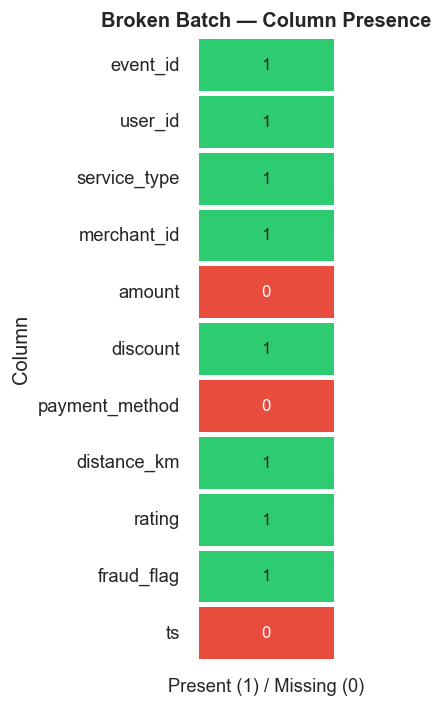

In [154]:
# heatmap: which columns are present vs missing in broken batch
presence_matrix = pd.DataFrame({
    'Column': REQUIRED_COLUMNS,
    'Present': [1 if c in broken_batch.columns else 0 for c in REQUIRED_COLUMNS]
}).set_index('Column')

fig, ax = plt.subplots(figsize=(3, 6))
sns.heatmap(
    presence_matrix, annot=True, cmap=['#E74C3C', '#2ECC71'], cbar=False,
    linewidths=2, linecolor='white', fmt='d', ax=ax,
    yticklabels=True, xticklabels=['Present (1) / Missing (0)']
)
ax.set_title('Broken Batch — Column Presence', fontweight='bold')
plt.tight_layout()
plt.show()

<a id="deteksi_event_duplikat"></a>
#### Deteksi Event Duplikat
Deteksi dan hapus duplikat saat proses ingestion.

In [155]:
df_full = pd.read_parquet('../datasets/goto_transactions.parquet')
original_count = len(df_full)

# inject 50 duplicate rows to simulate real ingestion issues
duplicates = df_full.sample(50, random_state=42)
df_with_dupes = pd.concat([df_full, duplicates], ignore_index=True)
injected_count = len(df_with_dupes)

print(f"Original:  {original_count:,}")
print(f"After injection: {injected_count:,}")
print(f"Injected duplicates: {injected_count - original_count}")

Original:  50,000
After injection: 50,050
Injected duplicates: 50


In [156]:
dup_mask = df_with_dupes.duplicated(subset=['event_id'], keep='first')
dup_records = df_with_dupes[dup_mask]
print(f"Detected duplicates: {len(dup_records)}")
display(dup_records.head(10))

df_deduped = df_with_dupes.drop_duplicates(subset=['event_id'], keep='first')
deduped_count = len(df_deduped)
print(f"\nAfter dedup: {deduped_count:,}")
assert deduped_count == original_count, "Dedup count mismatch!"
print("Deduplication restored original record count.")

Detected duplicates: 50


,event_id,user_id,service_type,merchant_id,amount,discount,payment_method,distance_km,rating,fraud_flag,ts
50000,gtx_33553,11725,tokopedia,2533,32539.0,10000,card,0.236773,3,0,2024-01-30 06:00:00
50001,gtx_9427,38334,goride,17248,80813.0,5000,cash,1.699555,4,0,2024-01-27 12:00:00
50002,gtx_199,34089,gofood,14332,69138.0,0,gopay,1.932914,3,0,2024-01-23 09:00:00
50003,gtx_12447,45716,goride,2610,42361.0,0,gopay,2.848830,5,0,2024-01-10 15:00:00
50004,gtx_39489,99423,gocar,13709,95193.0,20000,gopay,2.474966,2,0,2024-01-16 11:00:00
50005,gtx_42724,55646,gofood,3595,54436.0,5000,cash,7.870704,5,0,2024-01-01 12:00:00
50006,gtx_10822,42075,gofood,1390,69520.0,10000,gopay,3.377307,2,0,2024-01-25 07:00:00
50007,gtx_49498,58492,goride,698,78073.0,5000,card,6.509945,4,0,2024-01-01 17:00:00
50008,gtx_4144,17850,gofood,828,89806.0,10000,gopay,4.336011,3,0,2024-01-24 13:00:00
50009,gtx_36958,25029,gofood,16000,50415.0,0,card,3.184160,5,0,2024-01-08 06:00:00



After dedup: 50,000
Deduplication restored original record count.


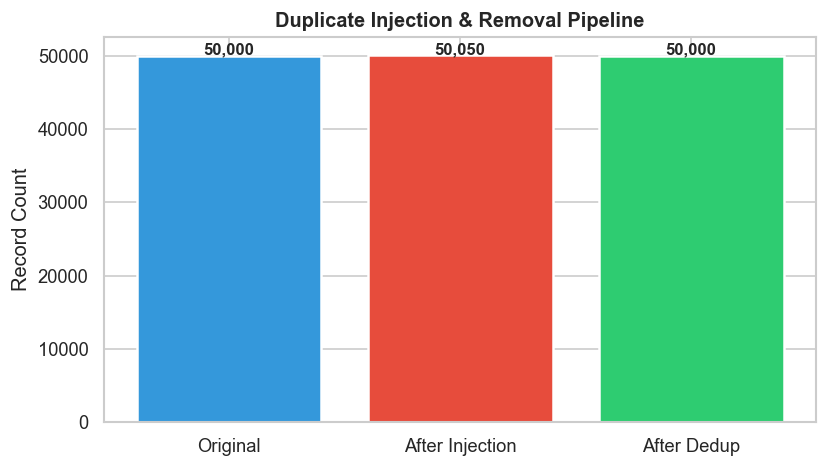

In [157]:
counts = pd.DataFrame({
    'Stage': ['Original', 'After Injection', 'After Dedup'],
    'Count': [original_count, injected_count, deduped_count]
})

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts['Stage'], counts['Count'],
              color=['#3498DB', '#E74C3C', '#2ECC71'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts['Count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontweight='bold')
ax.set_title('Duplicate Injection & Removal Pipeline', fontweight='bold')
ax.set_ylabel('Record Count')
plt.tight_layout()
plt.show()

<a id="schema_drift"></a>
#### Schema Drift
Simulasi perubahan tipe data amount dari numerik ke string.

In [158]:
df_drift = df.copy()

# simulate schema drift: cast amount from float64 to string
df_drift['amount'] = df_drift['amount'].astype(str)
print(f"Drifted 'amount' dtype: {df_drift['amount'].dtype}")

try:
    _ = df_drift['amount'].mean()
except TypeError as e:
    print(f"\nNumeric operation failed on drifted column: {e}")

Drifted 'amount' dtype: str

Numeric operation failed on drifted column: Cannot perform reduction 'mean' with string dtype


In [159]:
def validate_dtypes(batch_df: pd.DataFrame, expected: dict) -> pd.DataFrame:
    """Compare actual column dtypes against expected schema."""
    rows = []
    for col, exp_dtype in expected.items():
        if col in batch_df.columns:
            actual = str(batch_df[col].dtype)
            match = actual == exp_dtype
            rows.append({'column': col, 'expected': exp_dtype, 'actual': actual, 'status': '' if match else '❌ DRIFT'})
        else:
            rows.append({'column': col, 'expected': exp_dtype, 'actual': 'MISSING', 'status': '❌ MISSING'})
    return pd.DataFrame(rows)

drift_report = validate_dtypes(df_drift, EXPECTED_SCHEMA)
display(
    drift_report.style.map(
        lambda v: 'background-color: #FADBD8' if '❌' in str(v) else '',
        subset=['status']
    )
)
mismatches = drift_report[drift_report['status'].str.contains('❌')]
print(f"\nSchema mismatches found: {len(mismatches)}")

,column,expected,actual,status
0,event_id,object,str,❌ DRIFT
1,user_id,int64,int64,
2,service_type,object,str,❌ DRIFT
3,merchant_id,int64,int64,
4,amount,float64,str,❌ DRIFT
5,discount,int32,int32,
6,payment_method,object,str,❌ DRIFT
7,distance_km,float64,float64,
8,rating,int64,int64,
9,fraud_flag,int32,int32,



Schema mismatches found: 4


<a id="2b_raw_zone"></a>
### 2B. RAW Zone

<a id="checksum_immutability"></a>
#### Checksum & Immutability
Verifikasi file RAW tidak berubah sebelum dan sesudah pemrosesan.

In [160]:
# compute SHA-256 on raw file bytes
with open('../datasets/goto_transactions.parquet', 'rb') as f:
    raw_file_bytes = f.read()
checksum_before = hashlib.sha256(raw_file_bytes).hexdigest()
print(f"Checksum BEFORE processing: {checksum_before}")

record_count_before = len(pd.read_parquet('../datasets/goto_transactions.parquet'))

Checksum BEFORE processing: 83b26ce47c19e2e8128f9756ecbabc16e3257f93582b0fd3eb57d70c27ec9312


In [161]:
# simulate a processing step that only reads and manipulates a copy in memory
processing_df = pd.read_parquet('../datasets/goto_transactions.parquet')
processing_df['amount'] = processing_df['amount'] * 1.1
processing_df = processing_df[processing_df['fraud_flag'] == 0]
print(f"Processed copy: {len(processing_df)} rows (after fraud filter)")

Processed copy: 49000 rows (after fraud filter)


In [162]:
# re-read original and verify checksum unchanged
with open('../datasets/goto_transactions.parquet', 'rb') as f:
    raw_file_bytes_after = f.read()
checksum_after = hashlib.sha256(raw_file_bytes_after).hexdigest()
record_count_after = len(pd.read_parquet('../datasets/goto_transactions.parquet'))

print(f"Checksum AFTER processing:  {checksum_after}")
print(f"Records before: {record_count_before:,} | Records after: {record_count_after:,}")

assert checksum_before == checksum_after
assert record_count_before == record_count_after
print("\nRAW Zone immutability PASSED — file unchanged after processing.")

Checksum AFTER processing:  83b26ce47c19e2e8128f9756ecbabc16e3257f93582b0fd3eb57d70c27ec9312
Records before: 50,000 | Records after: 50,000

RAW Zone immutability PASSED — file unchanged after processing.


<a id="penyimpanan_historis"></a>
#### Penyimpanan Historis
Simulasi partisi data historis per tanggal.

In [163]:
df_raw = pd.read_parquet('../datasets/goto_transactions.parquet')
df_raw['date'] = df_raw['ts'].dt.date

unique_dates = df_raw['date'].nunique()
print(f"Unique dates in dataset: {unique_dates}")

# simulate writing to zone-partitioned paths
raw_store = {}
for date_val, group in df_raw.groupby('date'):
    raw_store[str(date_val)] = group.drop(columns=['date'])

storage_summary = pd.DataFrame([
    {'date': d, 'record_count': len(part)} for d, part in raw_store.items()
]).sort_values('date')

print(f"\nPartitions created: {len(raw_store)}")
display(storage_summary.head(10))

Unique dates in dataset: 30



Partitions created: 30


,date,record_count
0,2024-01-01,1581
1,2024-01-02,1630
2,2024-01-03,1663
3,2024-01-04,1659
4,2024-01-05,1692
5,2024-01-06,1672
6,2024-01-07,1651
7,2024-01-08,1678
8,2024-01-09,1680
9,2024-01-10,1622


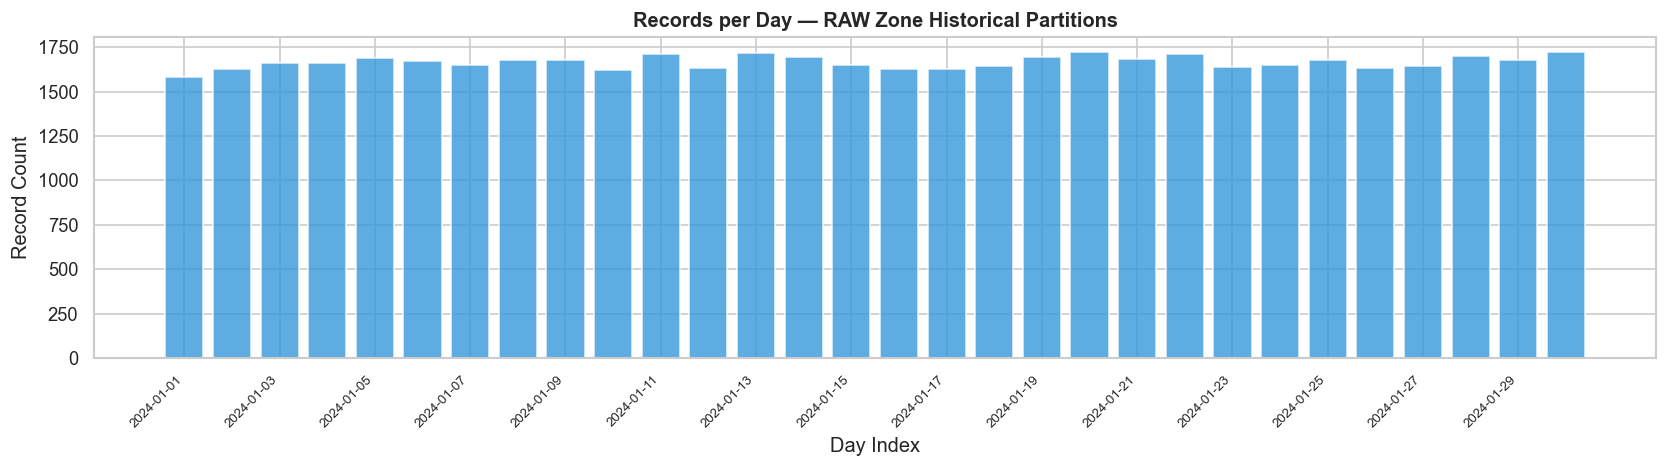

In [164]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(storage_summary)), storage_summary['record_count'],
       color='#3498DB', alpha=0.8, edgecolor='white')
ax.set_title('Records per Day — RAW Zone Historical Partitions', fontweight='bold')
ax.set_xlabel('Day Index')
ax.set_ylabel('Record Count')

tick_step = max(1, len(storage_summary) // 15)
ax.set_xticks(range(0, len(storage_summary), tick_step))
ax.set_xticklabels(storage_summary['date'].iloc[::tick_step], rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

<a id="2c_trusted_zone"></a>
### 2C. Trusted Zone

<a id="validasi_tipe_data"></a>
#### Validasi Tipe Data
Cek tipe data aktual terhadap skema yang diharapkan.

In [165]:
df_trusted = pd.read_parquet('../datasets/goto_transactions.parquet')

dtype_report = validate_dtypes(df_trusted, EXPECTED_SCHEMA)
display(
    dtype_report.style.map(
        lambda v: 'background-color: #D5F5E3' if '' in str(v) else 'background-color: #FADBD8',
        subset=['status']
    )
)

,column,expected,actual,status
0,event_id,object,str,❌ DRIFT
1,user_id,int64,int64,
2,service_type,object,str,❌ DRIFT
3,merchant_id,int64,int64,
4,amount,float64,float64,
5,discount,int32,int32,
6,payment_method,object,str,❌ DRIFT
7,distance_km,float64,float64,
8,rating,int64,int64,
9,fraud_flag,int32,int32,


<a id="duplikasi"></a>
#### Duplikasi

In [166]:
dup_mask_trusted = df_trusted.duplicated(subset=['event_id'], keep=False)
dup_count_trusted = dup_mask_trusted.sum()
dup_pct = dup_count_trusted / len(df_trusted) * 100

print(f"Duplicate event_id records: {dup_count_trusted}")
print(f"Duplicate percentage: {dup_pct:.4f}%")
if dup_count_trusted > 0:
    display(df_trusted[dup_mask_trusted].head(10))

Duplicate event_id records: 0
Duplicate percentage: 0.0000%


<a id="missing_value"></a>
#### Missing Value

,null_count,null_pct
event_id,0,0.0
user_id,0,0.0
service_type,0,0.0
merchant_id,0,0.0
amount,0,0.0
discount,0,0.0
payment_method,0,0.0
distance_km,0,0.0
rating,0,0.0
fraud_flag,0,0.0


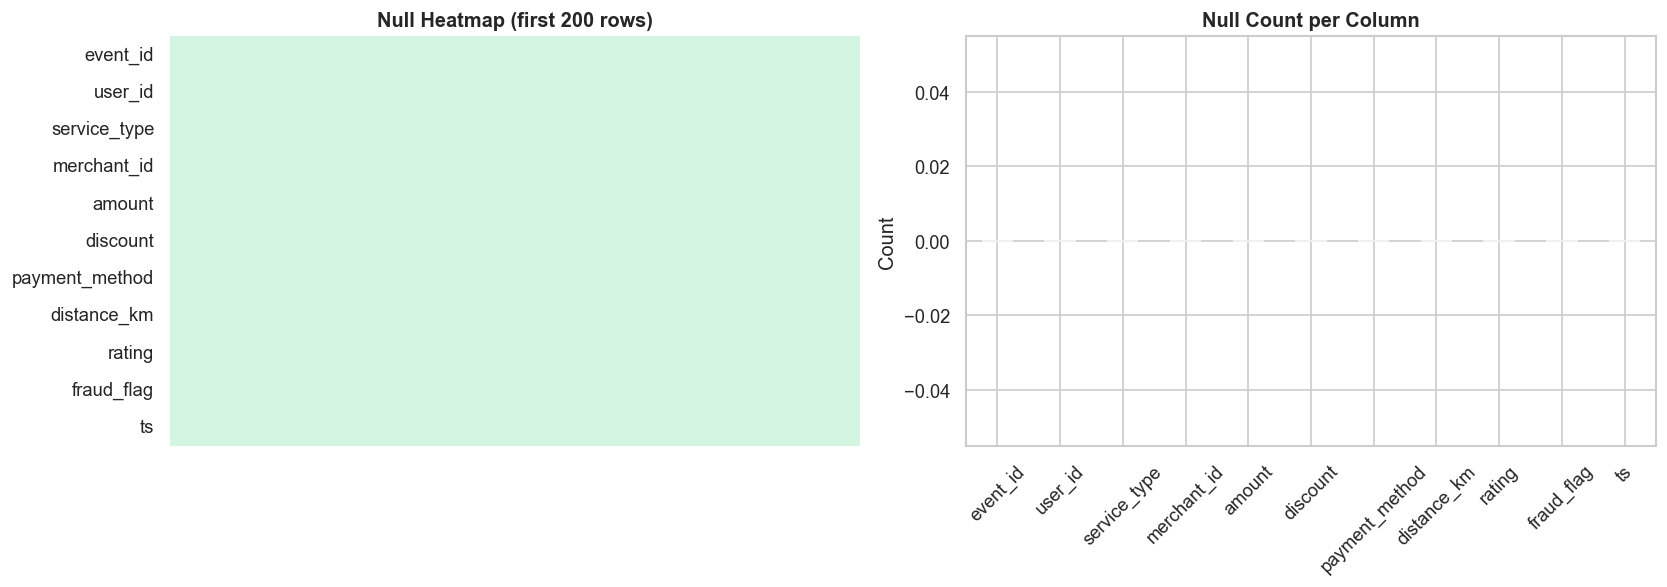

In [167]:
null_summary = df_trusted.isnull().sum().to_frame('null_count')
null_summary['null_pct'] = (null_summary['null_count'] / len(df_trusted) * 100).round(4)
display(null_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# heatmap of nulls
null_matrix = df_trusted.isnull().astype(int).head(200)
sns.heatmap(null_matrix.T, cbar=False, cmap=['#D5F5E3', '#E74C3C'],
            yticklabels=True, xticklabels=False, ax=axes[0])
axes[0].set_title('Null Heatmap (first 200 rows)', fontweight='bold')

# bar chart of null counts
null_counts_plot = df_trusted.isnull().sum()
null_counts_plot.plot.bar(ax=axes[1], color='#E74C3C', alpha=0.8, edgecolor='white')
axes[1].set_title('Null Count per Column', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<a id="nilai_tidak_masuk_akal"></a>
#### Nilai Tidak Masuk Akal
Deteksi nilai di luar batas logis bisnis.

,Check,Violation_Count
0,amount (<=0 or >10M),0
1,discount (<0 or >amount),68
2,rating (not 1-5),0
3,fraud_flag (not 0/1),0
4,distance_km (<0),0


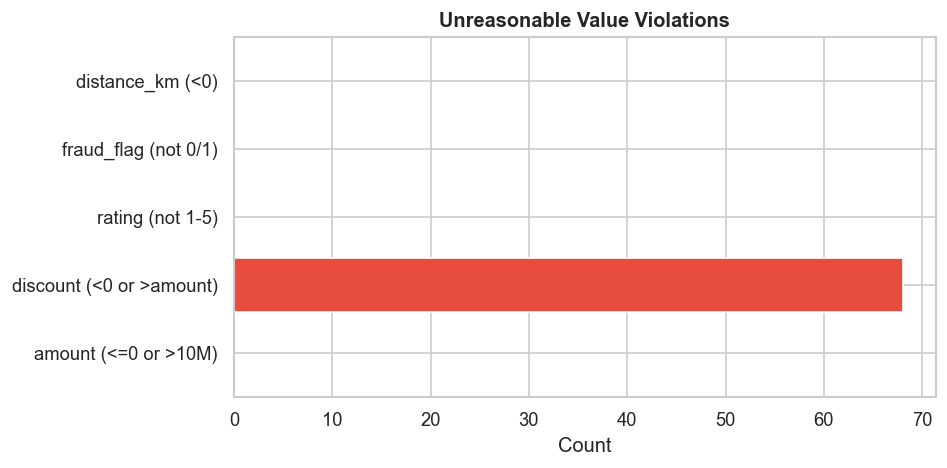

In [168]:
violations = {}

# amount <= 0 or amount > 10M
bad_amount = df_trusted[(df_trusted['amount'] <= 0) | (df_trusted['amount'] > 10_000_000)]
violations['amount (<=0 or >10M)'] = len(bad_amount)

# discount < 0 or discount > amount
bad_discount = df_trusted[(df_trusted['discount'] < 0) | (df_trusted['discount'] > df_trusted['amount'])]
violations['discount (<0 or >amount)'] = len(bad_discount)

# rating not in [1..5]
bad_rating = df_trusted[~df_trusted['rating'].isin([1, 2, 3, 4, 5])]
violations['rating (not 1-5)'] = len(bad_rating)

# fraud_flag not in [0, 1]
bad_fraud = df_trusted[~df_trusted['fraud_flag'].isin([0, 1])]
violations['fraud_flag (not 0/1)'] = len(bad_fraud)

# distance_km < 0
bad_distance = df_trusted[df_trusted['distance_km'] < 0]
violations['distance_km (<0)'] = len(bad_distance)

violations_df = pd.DataFrame(list(violations.items()), columns=['Check', 'Violation_Count'])
display(violations_df)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#E74C3C' if v > 0 else '#2ECC71' for v in violations_df['Violation_Count']]
ax.barh(violations_df['Check'], violations_df['Violation_Count'], color=colors, edgecolor='white')
ax.set_title('Unreasonable Value Violations', fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

In [169]:
# show sample rows for each violation type
for label, mask_df in [('amount', bad_amount), ('discount', bad_discount),
                        ('rating', bad_rating), ('fraud_flag', bad_fraud),
                        ('distance_km', bad_distance)]:
    if len(mask_df) > 0:
        print(f"\n--- {label} violations ({len(mask_df)} rows) ---")
        display(mask_df.head(5))


--- discount violations (68 rows) ---


,event_id,user_id,service_type,merchant_id,amount,discount,payment_method,distance_km,rating,fraud_flag,ts
1564,gtx_1564,59640,gocar,11606,17230.0,20000,gopay,3.250956,5,0,2024-01-04 18:00:00
1719,gtx_1719,17648,gofood,942,10782.0,20000,gopay,2.494499,5,0,2024-01-17 19:00:00
1806,gtx_1806,76426,tokopedia,14609,17338.0,20000,cash,3.791187,4,0,2024-01-26 05:00:00
2965,gtx_2965,98039,goride,6453,15015.0,20000,gopay,19.903859,1,0,2024-01-20 14:00:00
3305,gtx_3305,69954,tokopedia,18436,13721.0,20000,gopay,2.166856,5,0,2024-01-03 04:00:00


<a id="2d_refined_zone"></a>
### 2D. Refined Zone

<a id="konsistensi_data_analitik"></a>
#### Konsistensi Data Analitik
Agregasi data bersih untuk lapisan Refined.

In [170]:
# build trusted mask: only records passing all checks
trusted_mask = (
    (df_trusted['amount'] > 0) & (df_trusted['amount'] <= 10_000_000) &
    (df_trusted['discount'] >= 0) & (df_trusted['discount'] <= df_trusted['amount']) &
    (df_trusted['rating'].isin([1, 2, 3, 4, 5])) &
    (df_trusted['fraud_flag'].isin([0, 1])) &
    (df_trusted['distance_km'] >= 0) &
    (~df_trusted.duplicated(subset=['event_id'], keep='first'))
)

df_refined = df_trusted[trusted_mask].copy()
df_refined['date'] = df_refined['ts'].dt.date

dropped = len(df_trusted) - len(df_refined)
print(f"Raw count:     {len(df_trusted):,}")
print(f"Refined count: {len(df_refined):,}")
print(f"Dropped:       {dropped:,} ({dropped/len(df_trusted)*100:.2f}%)")

Raw count:     50,000
Refined count: 49,932
Dropped:       68 (0.14%)


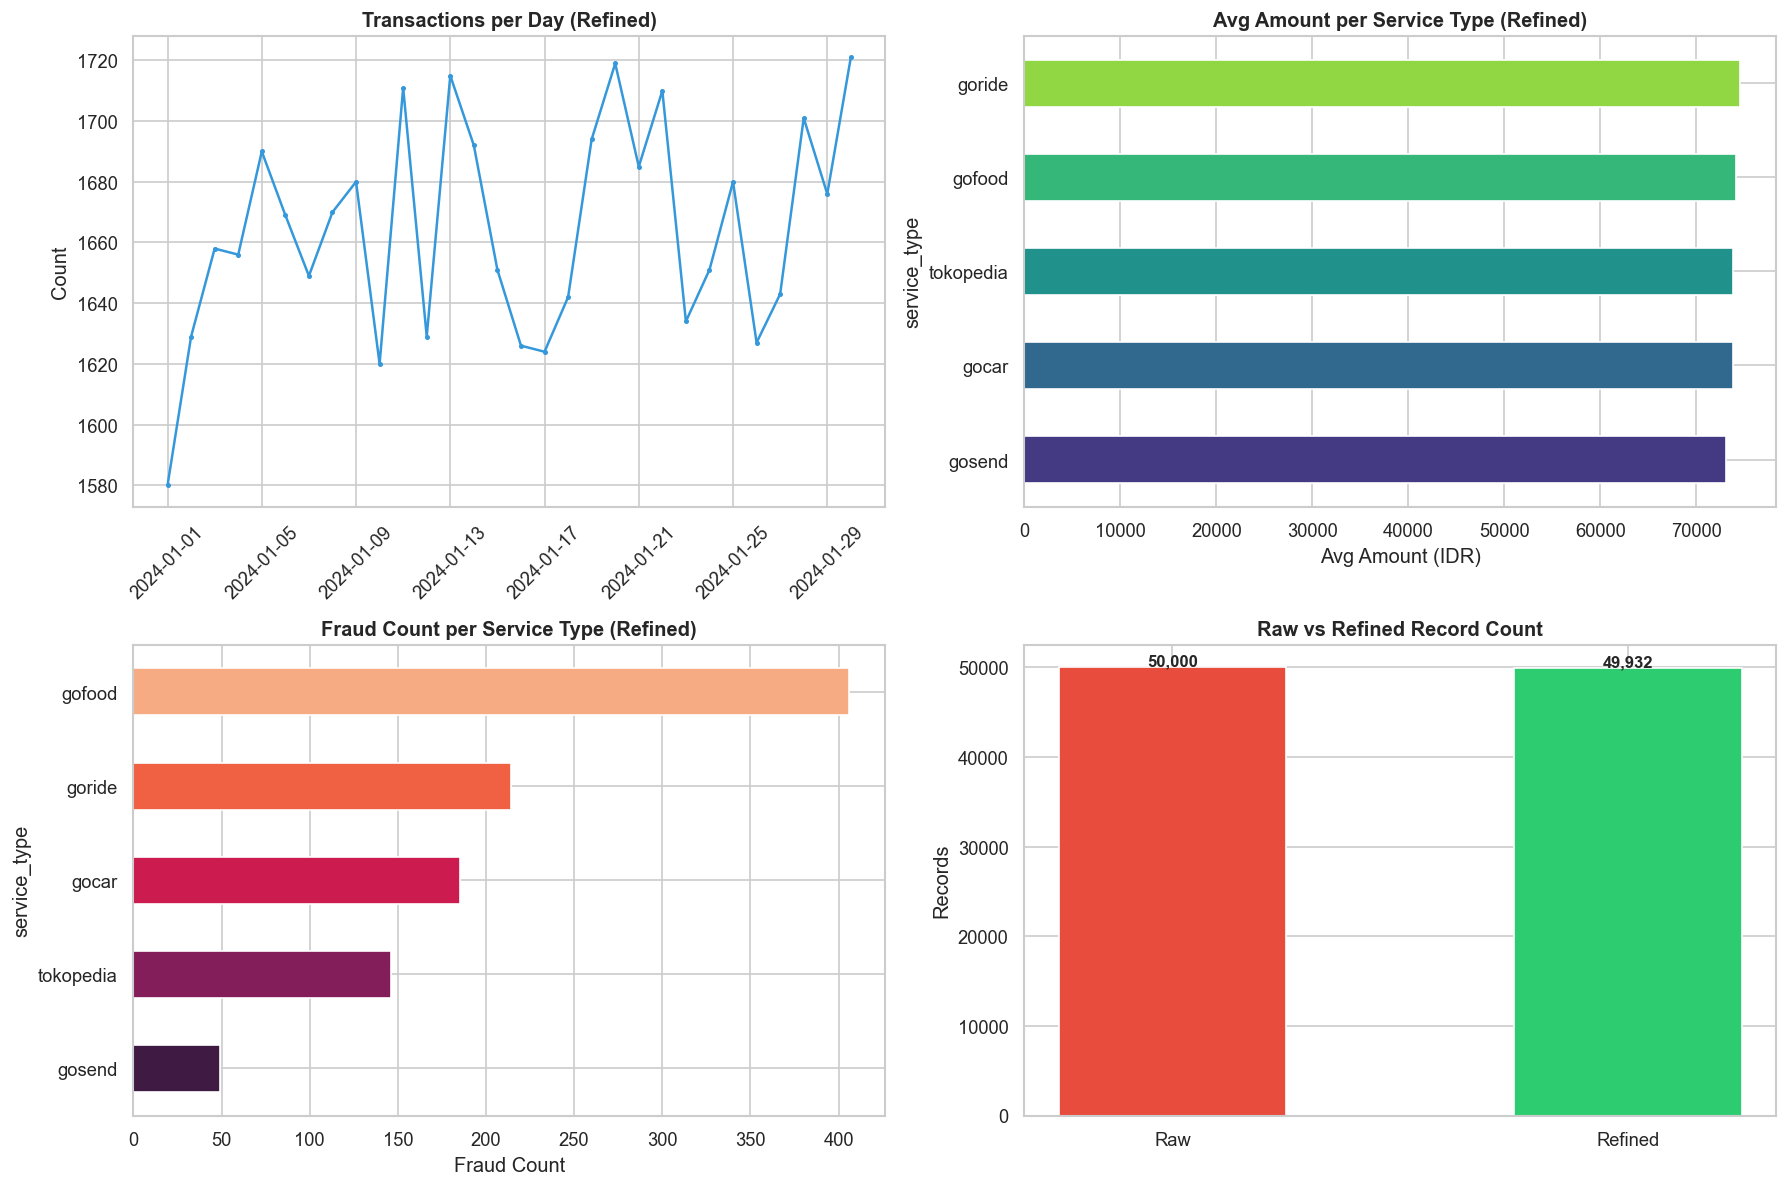

In [171]:
daily_agg = df_refined.groupby('date').agg(
    total_txn=('event_id', 'count'),
    avg_amount=('amount', 'mean'),
    fraud_count=('fraud_flag', 'sum')
).reset_index().sort_values('date')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# transactions per day
axes[0, 0].plot(daily_agg['date'], daily_agg['total_txn'],
                color='#3498DB', linewidth=1.5, marker='o', markersize=2)
axes[0, 0].set_title('Transactions per Day (Refined)', fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# average amount per service_type
svc_avg = df_refined.groupby('service_type')['amount'].mean().sort_values(ascending=True)
svc_avg.plot.barh(ax=axes[0, 1], color=sns.color_palette('viridis', len(svc_avg)), edgecolor='white')
axes[0, 1].set_title('Avg Amount per Service Type (Refined)', fontweight='bold')
axes[0, 1].set_xlabel('Avg Amount (IDR)')

# fraud count per service_type
svc_fraud = df_refined.groupby('service_type')['fraud_flag'].sum().sort_values(ascending=True)
svc_fraud.plot.barh(ax=axes[1, 0], color=sns.color_palette('rocket', len(svc_fraud)), edgecolor='white')
axes[1, 0].set_title('Fraud Count per Service Type (Refined)', fontweight='bold')
axes[1, 0].set_xlabel('Fraud Count')

# raw vs refined comparison
compare = pd.DataFrame({
    'Stage': ['Raw', 'Refined'],
    'Count': [len(df_trusted), len(df_refined)]
})
bars = axes[1, 1].bar(compare['Stage'], compare['Count'],
                       color=['#E74C3C', '#2ECC71'], edgecolor='white', width=0.5)
for bar, val in zip(bars, compare['Count']):
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                    f'{val:,}', ha='center', fontweight='bold')
axes[1, 1].set_title('Raw vs Refined Record Count', fontweight='bold')
axes[1, 1].set_ylabel('Records')

plt.tight_layout()
plt.show()

---
<a id="soal_3_pengujian_kualitas_data"></a>
## Soal 3 — Pengujian Kualitas Data
---

<a id="31_load_data_inisialisasi_flag"></a>
### 3.1 Load Data & Inisialisasi Flag
Load data dan siapkan kolom trusted_flag untuk penandaan kualitas.

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [173]:
df = pd.read_parquet('../datasets/goto_transactions.parquet')
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# initialize trusted_flag — all True, individual DQ checks will set False
df['trusted_flag'] = True

# track rejection reasons per row
df['rejection_reasons'] = [[] for _ in range(len(df))]

Loaded: 50,000 rows, 11 columns


<a id="32_dq_01_duplikasi_event_id"></a>
### 3.2 DQ-01: Duplikasi event_id

In [174]:
dup_mask = df.duplicated(subset=['event_id'], keep='first')
dup_count = dup_mask.sum()
print(f"Duplicate event_id count: {dup_count}")

if dup_count > 0:
    print("Sample duplicates:")
    display(df[dup_mask].head(10))

df.loc[dup_mask, 'trusted_flag'] = False
df.loc[dup_mask, 'rejection_reasons'] = df.loc[dup_mask, 'rejection_reasons'].apply(lambda x: x + ['duplicate_event_id'])
print(f"Flagged: {dup_count} rows")

Duplicate event_id count: 0
Flagged: 0 rows


<a id="33_dq_02_amount_negatif_nol"></a>
### 3.3 DQ-02: Amount Negatif / Nol

In [175]:
# inject test rows with negative and zero amounts
bad_negative = pd.DataFrame({
    'event_id': [f'dq02_neg_{i}' for i in range(5)],
    'user_id': np.random.randint(10000, 99999, 5),
    'service_type': 'gofood',
    'merchant_id': np.random.randint(100, 9999, 5),
    'amount': -500.0,
    'discount': 0,
    'payment_method': 'gopay',
    'distance_km': 2.5,
    'rating': 3,
    'fraud_flag': 0,
    'ts': pd.Timestamp('2024-06-15 12:00:00'),
    'trusted_flag': True,
    'rejection_reasons': [[] for _ in range(5)]
})

bad_zero = pd.DataFrame({
    'event_id': [f'dq02_zero_{i}' for i in range(5)],
    'user_id': np.random.randint(10000, 99999, 5),
    'service_type': 'goride',
    'merchant_id': np.random.randint(100, 9999, 5),
    'amount': 0.0,
    'discount': 0,
    'payment_method': 'cash',
    'distance_km': 1.0,
    'rating': 4,
    'fraud_flag': 0,
    'ts': pd.Timestamp('2024-06-15 13:00:00'),
    'trusted_flag': True,
    'rejection_reasons': [[] for _ in range(5)]
})

df = pd.concat([df, bad_negative, bad_zero], ignore_index=True)
print(f"After injection: {len(df):,} rows")

After injection: 50,010 rows


In [176]:
bad_amount_mask = df['amount'] <= 0
bad_amount_count = bad_amount_mask.sum()
print(f"Violations (amount <= 0): {bad_amount_count}")
display(df[bad_amount_mask].head(10))

df.loc[bad_amount_mask, 'trusted_flag'] = False
df.loc[bad_amount_mask, 'rejection_reasons'] = df.loc[bad_amount_mask, 'rejection_reasons'].apply(lambda x: x + ['negative_or_zero_amount'])
print(f"Flagged: {bad_amount_count} rows")

Violations (amount <= 0): 10


,event_id,user_id,service_type,merchant_id,amount,discount,payment_method,distance_km,rating,fraud_flag,ts,trusted_flag,rejection_reasons
50000,dq02_neg_0,25795,gofood,566,-500.0,0,gopay,2.5,3,0,2024-06-15 12:00:00,True,[]
50001,dq02_neg_1,10860,gofood,4526,-500.0,0,gopay,2.5,3,0,2024-06-15 12:00:00,True,[]
50002,dq02_neg_2,86820,gofood,5678,-500.0,0,gopay,2.5,3,0,2024-06-15 12:00:00,True,[]
50003,dq02_neg_3,64886,gofood,8422,-500.0,0,gopay,2.5,3,0,2024-06-15 12:00:00,True,[]
50004,dq02_neg_4,16265,gofood,1785,-500.0,0,gopay,2.5,3,0,2024-06-15 12:00:00,True,[]
50005,dq02_zero_0,74820,goride,7049,0.0,0,cash,1.0,4,0,2024-06-15 13:00:00,True,[]
50006,dq02_zero_1,10769,goride,2533,0.0,0,cash,1.0,4,0,2024-06-15 13:00:00,True,[]
50007,dq02_zero_2,69735,goride,5411,0.0,0,cash,1.0,4,0,2024-06-15 13:00:00,True,[]
50008,dq02_zero_3,72955,goride,5151,0.0,0,cash,1.0,4,0,2024-06-15 13:00:00,True,[]
50009,dq02_zero_4,74925,goride,6520,0.0,0,cash,1.0,4,0,2024-06-15 13:00:00,True,[]


Flagged: 10 rows


<a id="34_dq_03_missing_timestamp"></a>
### 3.4 DQ-03: Missing Timestamp

In [177]:
# inject 10 rows with ts = NaT
bad_ts = pd.DataFrame({
    'event_id': [f'dq03_nat_{i}' for i in range(10)],
    'user_id': np.random.randint(10000, 99999, 10),
    'service_type': 'gosend',
    'merchant_id': np.random.randint(100, 9999, 10),
    'amount': np.random.uniform(10000, 50000, 10),
    'discount': 0,
    'payment_method': 'gopay',
    'distance_km': np.random.uniform(0.5, 10, 10),
    'rating': np.random.randint(1, 6, 10),
    'fraud_flag': 0,
    'ts': pd.NaT,
    'trusted_flag': True,
    'rejection_reasons': [[] for _ in range(10)]
})

df = pd.concat([df, bad_ts], ignore_index=True)
print(f"After injection: {len(df):,} rows")

After injection: 50,020 rows


In [178]:
missing_ts_mask = df['ts'].isna()
missing_ts_count = missing_ts_mask.sum()
print(f"Missing timestamp (NaT): {missing_ts_count}")
display(df[missing_ts_mask].head(10))

df.loc[missing_ts_mask, 'trusted_flag'] = False
df.loc[missing_ts_mask, 'rejection_reasons'] = df.loc[missing_ts_mask, 'rejection_reasons'].apply(lambda x: x + ['missing_timestamp'])
print(f"Flagged: {missing_ts_count} rows")

Missing timestamp (NaT): 10


,event_id,user_id,service_type,merchant_id,amount,discount,payment_method,distance_km,rating,fraud_flag,ts,trusted_flag,rejection_reasons
50010,dq03_nat_0,93104,gosend,289,37212.301544,0,gopay,6.294968,2,0,NaT,True,[]
50011,dq03_nat_1,63707,gosend,2834,28019.970079,0,gopay,8.415352,2,0,NaT,True,[]
50012,dq03_nat_2,95305,gosend,3105,10530.598446,0,gopay,2.146964,4,0,NaT,True,[]
50013,dq03_nat_3,38693,gosend,4758,47688.070227,0,gopay,4.215076,2,0,NaT,True,[]
50014,dq03_nat_4,81932,gosend,1999,32531.528714,0,gopay,2.231243,2,0,NaT,True,[]
50015,dq03_nat_5,35658,gosend,7834,25416.660102,0,gopay,7.675933,4,0,NaT,True,[]
50016,dq03_nat_6,94478,gosend,1367,10638.650089,0,gopay,4.538981,4,0,NaT,True,[]
50017,dq03_nat_7,28431,gosend,1628,19235.753025,0,gopay,2.475446,1,0,NaT,True,[]
50018,dq03_nat_8,12747,gosend,3656,19641.018641,0,gopay,5.893153,5,0,NaT,True,[]
50019,dq03_nat_9,69150,gosend,3990,37330.540753,0,gopay,0.797476,5,0,NaT,True,[]


Flagged: 10 rows


<a id="35_dq_04_outlier_ekstrem"></a>
### 3.5 DQ-04: Outlier Ekstrem
Deteksi outlier menggunakan metode IQR dengan faktor 3x.

In [179]:
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

print(f"Q1: {Q1:,.2f}  Q3: {Q3:,.2f}  IQR: {IQR:,.2f}")
print(f"Lower bound: {lower_bound:,.2f}")
print(f"Upper bound: {upper_bound:,.2f}")

outlier_mask = (df['amount'] < lower_bound) | (df['amount'] > upper_bound)
outlier_count = outlier_mask.sum()
print(f"\nExtreme outliers: {outlier_count}")

df.loc[outlier_mask, 'trusted_flag'] = False
df.loc[outlier_mask, 'rejection_reasons'] = df.loc[outlier_mask, 'rejection_reasons'].apply(lambda x: x + ['extreme_outlier'])
print(f"Flagged: {outlier_count} rows")

Q1: 43,120.50  Q3: 86,246.75  IQR: 43,126.25
Lower bound: -86,258.25
Upper bound: 215,625.50

Extreme outliers: 1015
Flagged: 1015 rows


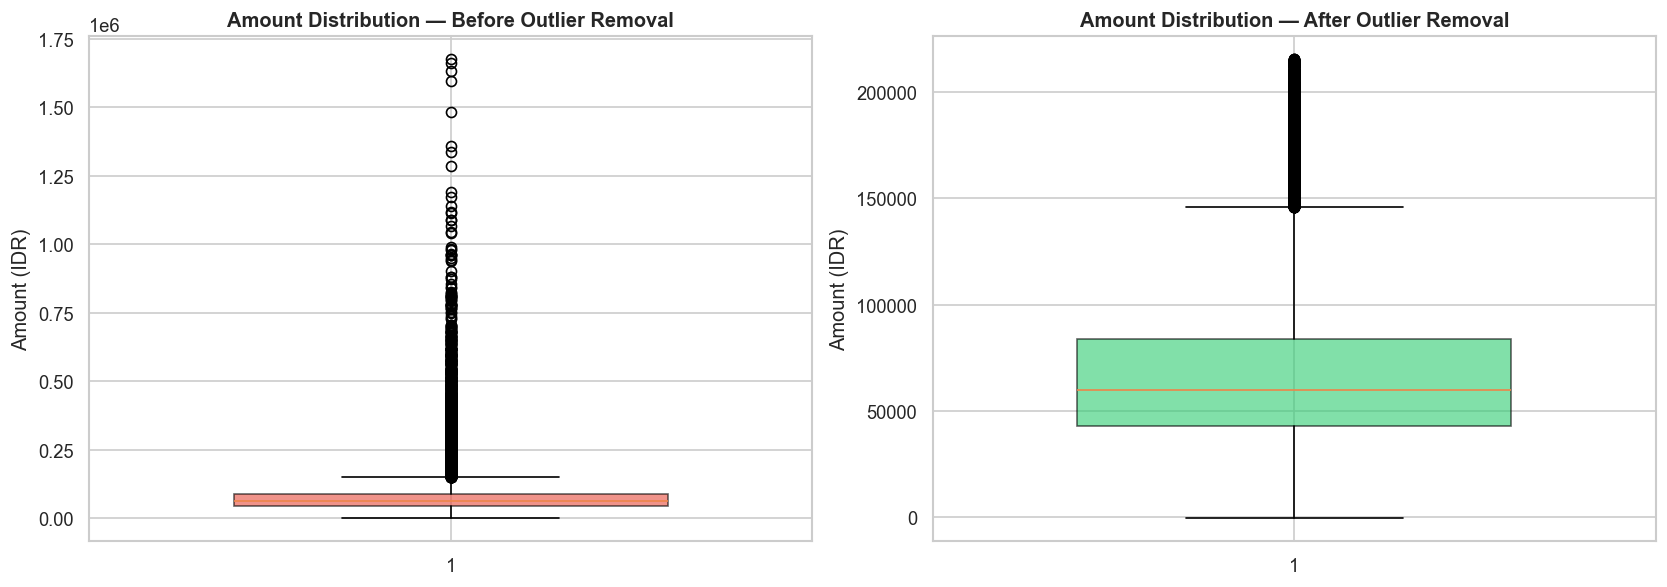

In [180]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['amount'].dropna(), vert=True, widths=0.6,
                patch_artist=True, boxprops=dict(facecolor='#E74C3C', alpha=0.6))
axes[0].set_title('Amount Distribution — Before Outlier Removal', fontweight='bold')
axes[0].set_ylabel('Amount (IDR)')

clean_amount = df.loc[~outlier_mask, 'amount'].dropna()
axes[1].boxplot(clean_amount, vert=True, widths=0.6,
                patch_artist=True, boxprops=dict(facecolor='#2ECC71', alpha=0.6))
axes[1].set_title('Amount Distribution — After Outlier Removal', fontweight='bold')
axes[1].set_ylabel('Amount (IDR)')

plt.tight_layout()
plt.show()

<a id="36_dq_05_konsistensi_fraud_flag"></a>
### 3.6 DQ-05: Konsistensi fraud_flag

In [181]:
# inject 10 rows with fraud_flag = 99
bad_fraud = pd.DataFrame({
    'event_id': [f'dq05_fraud_{i}' for i in range(10)],
    'user_id': np.random.randint(10000, 99999, 10),
    'service_type': 'tokopedia',
    'merchant_id': np.random.randint(100, 9999, 10),
    'amount': np.random.uniform(20000, 100000, 10),
    'discount': 0,
    'payment_method': 'card',
    'distance_km': 0.0,
    'rating': 5,
    'fraud_flag': 99,
    'ts': pd.Timestamp('2024-07-10 10:00:00'),
    'trusted_flag': True,
    'rejection_reasons': [[] for _ in range(10)]
})

df = pd.concat([df, bad_fraud], ignore_index=True)
print(f"After injection: {len(df):,} rows")

After injection: 50,030 rows


In [182]:
bad_fraud_mask = ~df['fraud_flag'].isin([0, 1])
bad_fraud_count = bad_fraud_mask.sum()
print(f"Invalid fraud_flag values: {bad_fraud_count}")
display(df[bad_fraud_mask].head(10))

df.loc[bad_fraud_mask, 'trusted_flag'] = False
df.loc[bad_fraud_mask, 'rejection_reasons'] = df.loc[bad_fraud_mask, 'rejection_reasons'].apply(lambda x: x + ['invalid_fraud_flag'])
print(f"Flagged: {bad_fraud_count} rows")

Invalid fraud_flag values: 10


,event_id,user_id,service_type,merchant_id,amount,discount,payment_method,distance_km,rating,fraud_flag,ts,trusted_flag,rejection_reasons
50020,dq05_fraud_0,84065,tokopedia,2162,76548.587508,0,card,0.0,5,99,2024-07-10 10:00:00,True,[]
50021,dq05_fraud_1,92798,tokopedia,164,78320.573443,0,card,0.0,5,99,2024-07-10 10:00:00,True,[]
50022,dq05_fraud_2,19268,tokopedia,8106,81701.627735,0,card,0.0,5,99,2024-07-10 10:00:00,True,[]
50023,dq05_fraud_3,96807,tokopedia,2668,25923.572139,0,card,0.0,5,99,2024-07-10 10:00:00,True,[]
50024,dq05_fraud_4,22185,tokopedia,5563,48677.258284,0,card,0.0,5,99,2024-07-10 10:00:00,True,[]
50025,dq05_fraud_5,73704,tokopedia,2127,29269.524762,0,card,0.0,5,99,2024-07-10 10:00:00,True,[]
50026,dq05_fraud_6,96779,tokopedia,2795,89048.274070,0,card,0.0,5,99,2024-07-10 10:00:00,True,[]
50027,dq05_fraud_7,49099,tokopedia,9787,69863.850146,0,card,0.0,5,99,2024-07-10 10:00:00,True,[]
50028,dq05_fraud_8,18571,tokopedia,5358,46471.841988,0,card,0.0,5,99,2024-07-10 10:00:00,True,[]
50029,dq05_fraud_9,48044,tokopedia,5718,25084.668023,0,card,0.0,5,99,2024-07-10 10:00:00,True,[]


Flagged: 10 rows


<a id="37_ringkasan_trusted_vs_rejected"></a>
### 3.7 Ringkasan Trusted vs Rejected
Ringkasan hasil pengujian kualitas dan risiko data kotor di Refined.

In [183]:
total_records = len(df)
trusted_count = df['trusted_flag'].sum()
rejected_count = total_records - trusted_count

print(f"Total records:    {total_records:,}")
print(f"Trusted:          {trusted_count:,} ({trusted_count/total_records*100:.2f}%)")
print(f"Rejected:         {rejected_count:,} ({rejected_count/total_records*100:.2f}%)")

Total records:    50,030
Trusted:          48,985 (97.91%)
Rejected:         1,045 (2.09%)


In [184]:
# rejection reason breakdown
all_reasons = []
for reasons in df.loc[~df['trusted_flag'], 'rejection_reasons']:
    all_reasons.extend(reasons)

reason_counts = pd.Series(all_reasons).value_counts()
print("Rejection Reason Breakdown:")
display(reason_counts.to_frame('count'))

Rejection Reason Breakdown:


,count
extreme_outlier,1015
negative_or_zero_amount,10
missing_timestamp,10
invalid_fraud_flag,10


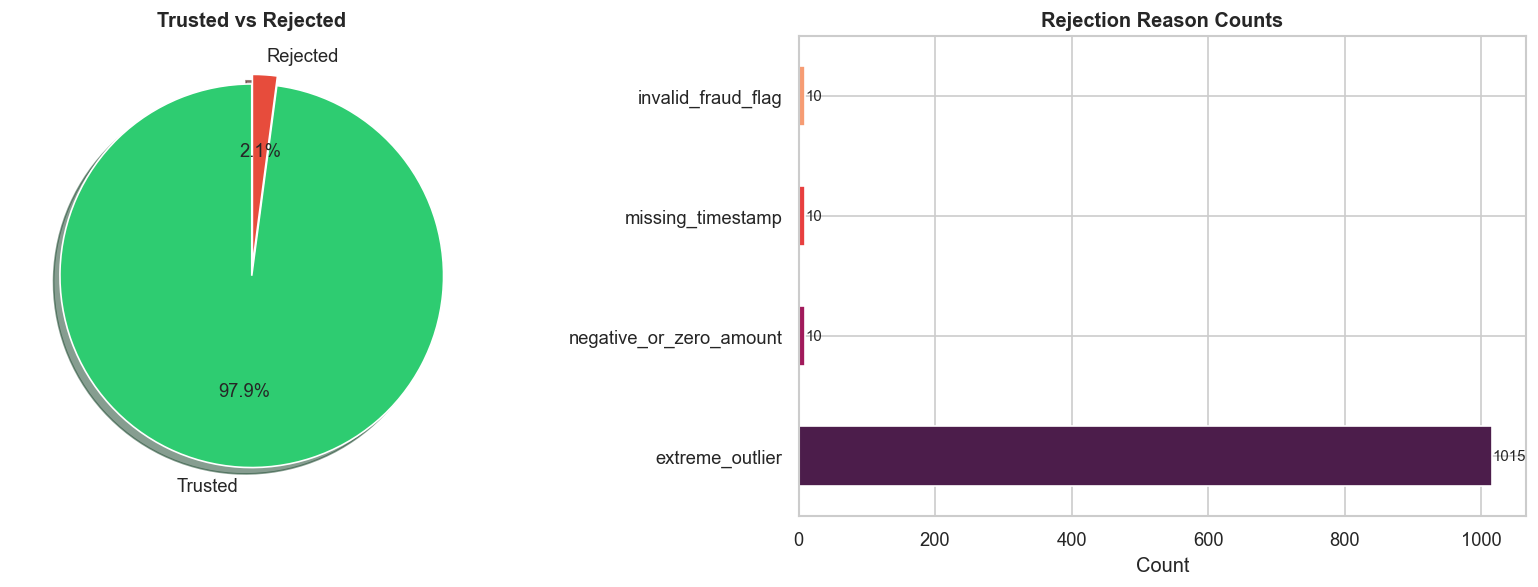

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# pie chart
axes[0].pie(
    [trusted_count, rejected_count],
    labels=['Trusted', 'Rejected'],
    colors=['#2ECC71', '#E74C3C'],
    autopct='%1.1f%%', startangle=90,
    explode=(0, 0.05), shadow=True, textprops={'fontsize': 11}
)
axes[0].set_title('Trusted vs Rejected', fontweight='bold')

# bar chart of rejection reasons
reason_counts.plot.barh(ax=axes[1], color=sns.color_palette('rocket', len(reason_counts)), edgecolor='white')
axes[1].set_title('Rejection Reason Counts', fontweight='bold')
axes[1].set_xlabel('Count')
for i, v in enumerate(reason_counts.values):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [186]:
df_trusted = df[df['trusted_flag']].drop(columns=['trusted_flag', 'rejection_reasons']).copy()
print(f"Trusted dataset saved: {len(df_trusted):,} rows")

Trusted dataset saved: 48,985 rows


<a id="38_dampak_data_kotor_di_refined"></a>
### 3.8 Dampak Data Kotor di Refined

In [187]:
# compare aggregations WITH dirty data vs WITHOUT
df_all = df.drop(columns=['trusted_flag', 'rejection_reasons'])

agg_dirty = df_all.groupby('service_type')['amount'].sum().sort_index()
agg_clean = df_trusted.groupby('service_type')['amount'].sum().sort_index()

comparison = pd.DataFrame({
    'With Dirty Data (IDR)': agg_dirty,
    'Without Dirty Data (IDR)': agg_clean,
}).fillna(0)
comparison['Distortion (IDR)'] = comparison['With Dirty Data (IDR)'] - comparison['Without Dirty Data (IDR)']
comparison['Distortion (%)'] = (comparison['Distortion (IDR)'] / comparison['Without Dirty Data (IDR)'] * 100).round(2)

display(comparison)

,With Dirty Data (IDR),Without Dirty Data (IDR),Distortion (IDR),Distortion (%)
service_type,,,,
gocar,6.648026e+08,5.966821e+08,6.812051e+07,11.42
gofood,1.482328e+09,1.326445e+09,1.558834e+08,11.75
goride,8.163393e+08,7.200724e+08,9.626688e+07,13.37
gosend,1.863930e+08,1.655797e+08,2.081329e+07,12.57
tokopedia,5.513535e+08,4.947095e+08,5.664397e+07,11.45


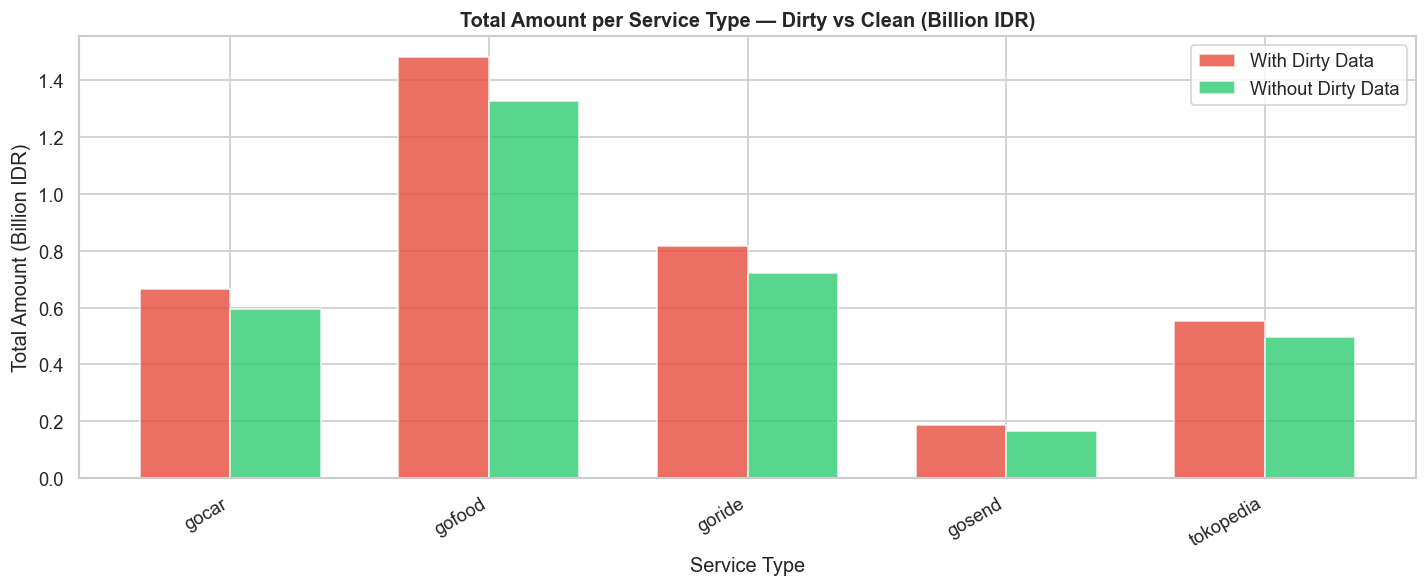

In [188]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(comparison))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['With Dirty Data (IDR)'] / 1e9,
               width, label='With Dirty Data', color='#E74C3C', alpha=0.8, edgecolor='white')
bars2 = ax.bar(x + width/2, comparison['Without Dirty Data (IDR)'] / 1e9,
               width, label='Without Dirty Data', color='#2ECC71', alpha=0.8, edgecolor='white')

ax.set_title('Total Amount per Service Type — Dirty vs Clean (Billion IDR)', fontweight='bold')
ax.set_xlabel('Service Type')
ax.set_ylabel('Total Amount (Billion IDR)')
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=30, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

---
<a id="soal_4_pemrosesan_dengan_apache_spark"></a>
## Soal 4 — Pemrosesan dengan Apache Spark
---

In [189]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "pyspark", "-q"])

CompletedProcess(args=['c:\\Program Files\\Python312\\python.exe', '-m', 'pip', 'install', 'pyspark', '-q'], returncode=0)

In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, count, avg, to_date, udf
from pyspark.sql.types import IntegerType

# ensure compatibility with modern Java versions
JAVA_OPTS = " ".join([
    "--add-opens java.base/sun.nio.ch=ALL-UNNAMED",
    "--add-opens java.base/java.lang=ALL-UNNAMED",
    "--add-opens java.base/java.lang.invoke=ALL-UNNAMED",
    "--add-opens java.base/java.io=ALL-UNNAMED",
    "--add-opens java.base/java.net=ALL-UNNAMED",
    "--add-opens java.base/java.nio=ALL-UNNAMED",
    "--add-opens java.base/java.util=ALL-UNNAMED",
    "--add-opens java.base/java.util.concurrent=ALL-UNNAMED",
    "--add-opens java.base/java.util.concurrent.atomic=ALL-UNNAMED",
    "--add-opens java.base/sun.security.action=ALL-UNNAMED",
    "--add-opens java.base/javax.security.auth=ALL-UNNAMED",
])
os.environ["PYSPARK_SUBMIT_ARGS"] = f'--conf spark.driver.extraJavaOptions="{JAVA_OPTS}" pyspark-shell'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

<a id="41_inisialisasi_sparksession"></a>
### 4.1 Inisialisasi SparkSession

In [191]:
import subprocess

result = subprocess.run(
    ["java", "-version"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)

print(result.stderr)

openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment Temurin-17.0.18+8 (build 17.0.18+8)
OpenJDK 64-Bit Server VM Temurin-17.0.18+8 (build 17.0.18+8, mixed mode, sharing)



In [192]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("test") \
    .master("local[4]") \
    .config("spark.driver.memory", "2g") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.local.ip", "127.0.0.1") \
    .config("spark.driver.extraJavaOptions", "-Djava.net.preferIPv4Stack=true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"Spark Session Active: v{spark.version}")

Spark Session Active: v4.1.1


<a id="42_load_partisi"></a>
### 4.2 Load & Partisi
Load data ke Spark dan analisis distribusi partisi.

In [193]:
import pandas as pd

spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")
spark.conf.set("spark.sql.parquet.enableVectorizedReader", "false")

# Workaround for PySpark PARQUET_TYPE_ILLEGAL with INT64 (TIMESTAMP(NANOS,false))
# Read using pandas and convert datetime64[ns] to [us] to ensure Spark compatibility, avoiding string casts.
df_pd = pd.read_parquet('../datasets/goto_transactions.parquet')
if 'ts' in df_pd.columns and str(df_pd['ts'].dtype).startswith('datetime64[ns'):
    df_pd['ts'] = df_pd['ts'].astype('datetime64[us]')
df_spark = spark.createDataFrame(df_pd)

df_spark.printSchema()
print(f"Total records: {df_spark.count():,}")

initial_partitions = df_spark.rdd.getNumPartitions()
print(f"Initial number of partitions: {initial_partitions}")

root
 |-- event_id: string (nullable = true)
 |-- user_id: long (nullable = true)
 |-- service_type: string (nullable = true)
 |-- merchant_id: long (nullable = true)
 |-- amount: double (nullable = true)
 |-- discount: integer (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- distance_km: double (nullable = true)
 |-- rating: long (nullable = true)
 |-- fraud_flag: integer (nullable = true)
 |-- ts: timestamp (nullable = true)

Total records: 50,000
Initial number of partitions: 4


In [194]:
# partition by date: extract date from ts
df_spark = df_spark.withColumn('date', to_date('ts'))

unique_dates = df_spark.select('date').distinct().count()
print(f"Found {unique_dates} unique dates.")

# repartitioning aligns data by day, optimizing subsequent aggregations
df_repartitioned = df_spark.repartition(unique_dates, 'date')
new_partitions = df_repartitioned.rdd.getNumPartitions()
print(f"New number of partitions after repartitioning by date: {new_partitions}")

Found 30 unique dates.
New number of partitions after repartitioning by date: 30


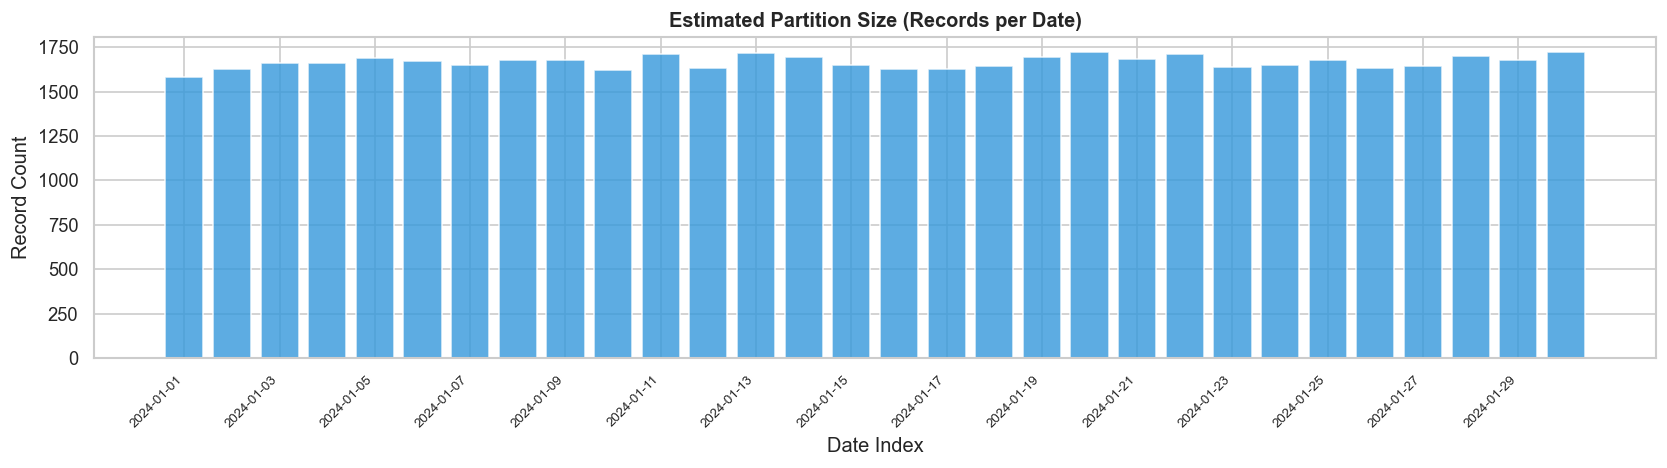

In [195]:
# bar chart: record count per date (partition size estimate)
pdf_partition_sizes = df_repartitioned.groupBy('date').count().orderBy('date').toPandas()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(pdf_partition_sizes)), pdf_partition_sizes['count'],
       color='#3498DB', alpha=0.8, edgecolor='white')
ax.set_title('Estimated Partition Size (Records per Date)', fontweight='bold')
ax.set_xlabel('Date Index')
ax.set_ylabel('Record Count')

tick_step = max(1, len(pdf_partition_sizes) // 15)
ax.set_xticks(range(0, len(pdf_partition_sizes), tick_step))
ax.set_xticklabels(pdf_partition_sizes['date'].iloc[::tick_step].astype(str), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

<a id="43_agregasi_metrik"></a>
### 4.3 Agregasi Metrik

<a id="total_amount_per_hari"></a>
#### Total Amount per Hari

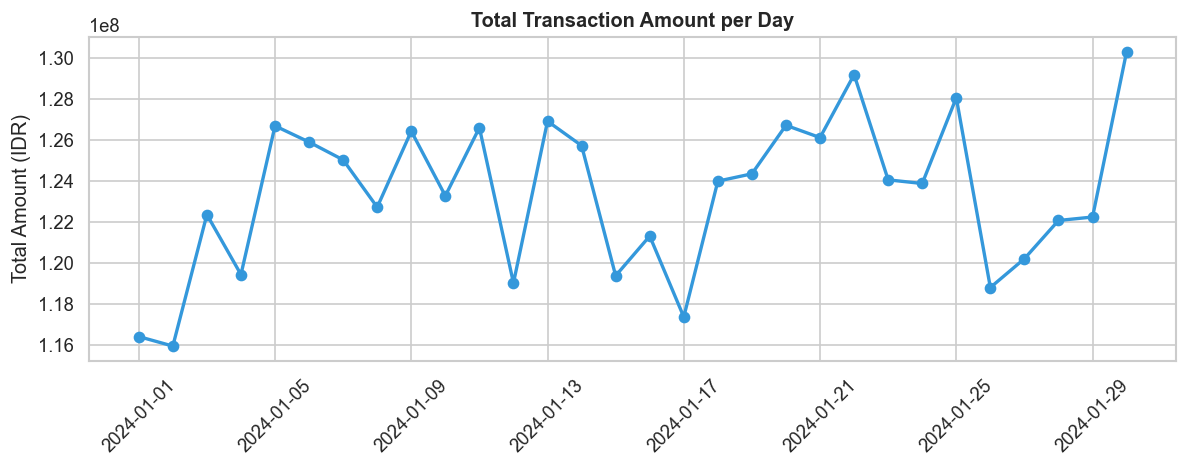

In [196]:
daily_amount = df_repartitioned.groupBy('date') \
    .agg(sum('amount').alias('total_amount')) \
    .orderBy('date')

pdf_daily = daily_amount.toPandas()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pdf_daily['date'], pdf_daily['total_amount'], marker='o', color='#3498DB', linewidth=2)
ax.set_title('Total Transaction Amount per Day', fontweight='bold')
ax.set_ylabel('Total Amount (IDR)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

<a id="jumlah_transaksi_per_user"></a>
#### Jumlah Transaksi per User

C:\Users\josgi\AppData\Local\Temp\ipykernel_17284\3545934214.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf_users, x='user_id', y='count', palette='viridis', ax=ax, edgecolor='white')


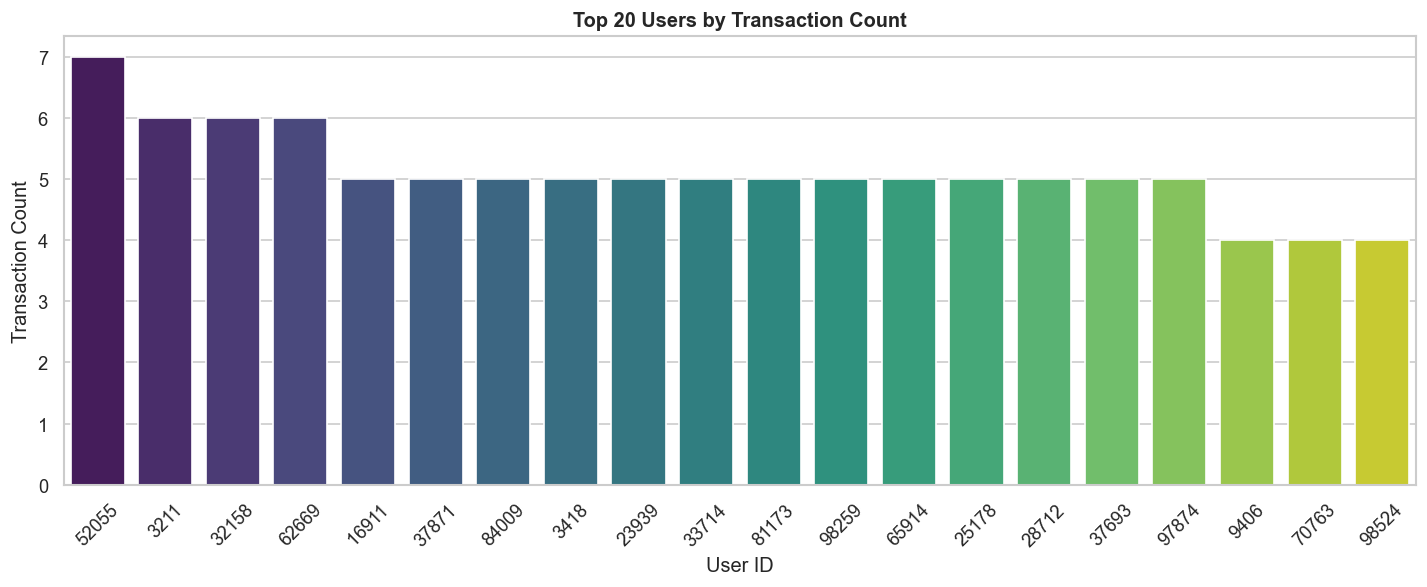

In [197]:
user_txns = df_repartitioned.groupBy('user_id').count() \
    .orderBy(col('count').desc()) \
    .limit(20)

pdf_users = user_txns.toPandas()
pdf_users['user_id'] = pdf_users['user_id'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=pdf_users, x='user_id', y='count', palette='viridis', ax=ax, edgecolor='white')
ax.set_title('Top 20 Users by Transaction Count', fontweight='bold')
ax.set_xlabel('User ID')
ax.set_ylabel('Transaction Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

<a id="persentase_fraud_per_service_type"></a>
#### Persentase Fraud per Service Type

C:\Users\josgi\AppData\Local\Temp\ipykernel_17284\3815075959.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf_fraud, x='service_type', y='fraud_pct', palette='rocket', ax=ax, edgecolor='white')


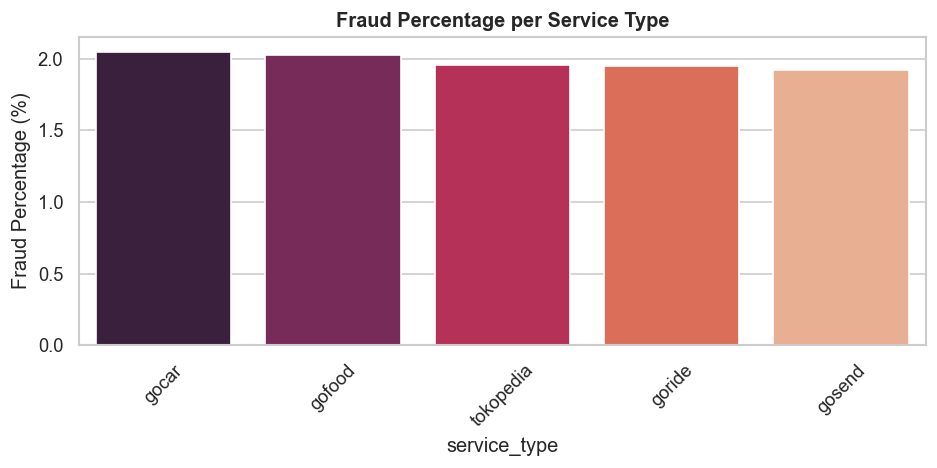

In [198]:
fraud_agg = df_repartitioned.groupBy('service_type').agg(
    count('*').alias('total'),
    sum('fraud_flag').alias('fraud_count')
)

fraud_agg = fraud_agg.withColumn('fraud_pct', (col('fraud_count') / col('total')) * 100) \
    .orderBy(col('fraud_pct').desc())

pdf_fraud = fraud_agg.toPandas()

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=pdf_fraud, x='service_type', y='fraud_pct', palette='rocket', ax=ax, edgecolor='white')
ax.set_title('Fraud Percentage per Service Type', fontweight='bold')
ax.set_ylabel('Fraud Percentage (%)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

<a id="rata_rata_amount_per_payment_method"></a>
#### Rata-rata Amount per Payment Method

C:\Users\josgi\AppData\Local\Temp\ipykernel_17284\1540532702.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf_payment, x='payment_method', y='avg_amount', palette='mako', ax=ax, edgecolor='white')


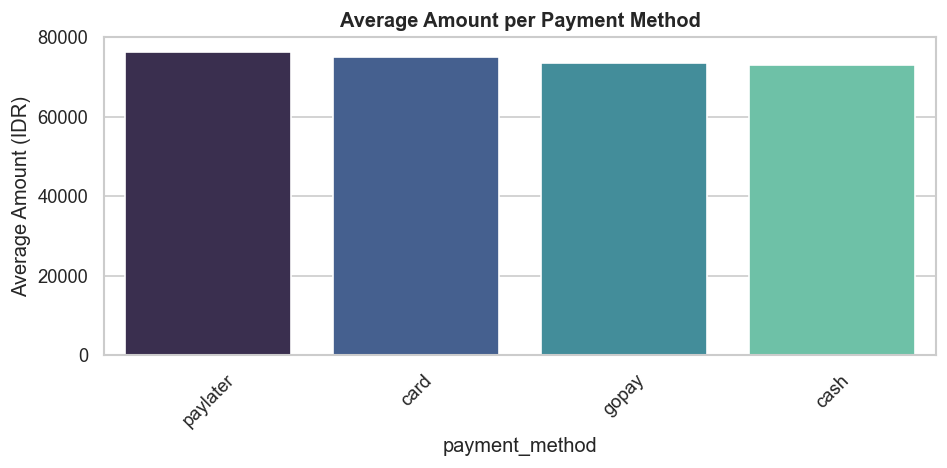

In [199]:
payment_avg = df_repartitioned.groupBy('payment_method').agg(avg('amount').alias('avg_amount')) \
    .orderBy(col('avg_amount').desc())

pdf_payment = payment_avg.toPandas()

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=pdf_payment, x='payment_method', y='avg_amount', palette='mako', ax=ax, edgecolor='white')
ax.set_title('Average Amount per Payment Method', fontweight='bold')
ax.set_ylabel('Average Amount (IDR)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

<a id="44_fault_tolerance"></a>
### 4.4 Fault Tolerance
Perilaku Spark saat satu task gagal dalam pemrosesan dataset transaksi.

In [200]:
print(f"Current partitions: {df_repartitioned.rdd.getNumPartitions()}")

@udf(returnType=IntegerType())
def buggy_transformation(val):
    if val >= 5:
        raise RuntimeError("Simulated Task Failure: Value too high!")
    return val * 2

try:
    df_fail = df_repartitioned.withColumn('rating_x2', buggy_transformation(col('rating')))
    print("Attempting to count... this might fail.")
    count_res = df_fail.count()
except Exception as e:
    print("\nTask failure exception caught:")
    print(str(e)[:200] + "...")
    
print("\nSetting up local checkpointing to break lineage and save intermediate state (Windows compatible):")
# spark.sparkContext.setCheckpointDir('./spark_checkpoints')  # Bypassed to avoid Hadoop winutils error on Windows
df_checkpointed = df_repartitioned.localCheckpoint()
print(f"Checkpointed dataframe partitions: {df_checkpointed.rdd.getNumPartitions()}")
print("Notice: Data is safely materialized to local executor disk.")

Current partitions: 30
Attempting to count... this might fail.

Setting up local checkpointing to break lineage and save intermediate state (Windows compatible):
Checkpointed dataframe partitions: 30
Notice: Data is safely materialized to local executor disk.


<a id="45_spark_vs_mapreduce"></a>
### 4.5 Spark vs MapReduce
Perbandingan Spark dan MapReduce untuk analitik transaksi iteratif.

In [201]:
comparison = pd.DataFrame({
    'Dimension': [
        'Processing model', 
        'Iterative operations', 
        'Aggregation speed', 
        'Fault tolerance', 
        'API richness',
        'Ease of use',
        'Ecosystem'
    ],
    'Spark': [
        'In-memory DAG',
        'Native (RDD/DataFrame)',
        'Single-pass with shuffle',
        'RDD lineage / checkpoint',
        'SQL, DataFrame, MLlib, Streaming',
        'High-level APIs (Python, Scala, R)',
        'Spark SQL, MLlib, GraphX, Structured Streaming'
    ],
    'MapReduce': [
        'Disk-based MapReduce cycles',
        'Requires multiple MR jobs',
        'Multi-pass disk I/O',
        'HDFS replication',
        'Java/Python MR only',
        'Verbose boilerplate code',
        'Hadoop ecosystem (Hive, Pig)'
    ]
})

display(comparison.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2C3E50'), ('color', 'white'), ('text-align', 'center')]}
]))

,Dimension,Spark,MapReduce
0,Processing model,In-memory DAG,Disk-based MapReduce cycles
1,Iterative operations,Native (RDD/DataFrame),Requires multiple MR jobs
2,Aggregation speed,Single-pass with shuffle,Multi-pass disk I/O
3,Fault tolerance,RDD lineage / checkpoint,HDFS replication
4,API richness,"SQL, DataFrame, MLlib, Streaming",Java/Python MR only
5,Ease of use,"High-level APIs (Python, Scala, R)",Verbose boilerplate code
6,Ecosystem,"Spark SQL, MLlib, GraphX, Structured Streaming","Hadoop ecosystem (Hive, Pig)"


Pandas execution time: 0.0040 seconds
Spark execution time:  0.4319 seconds


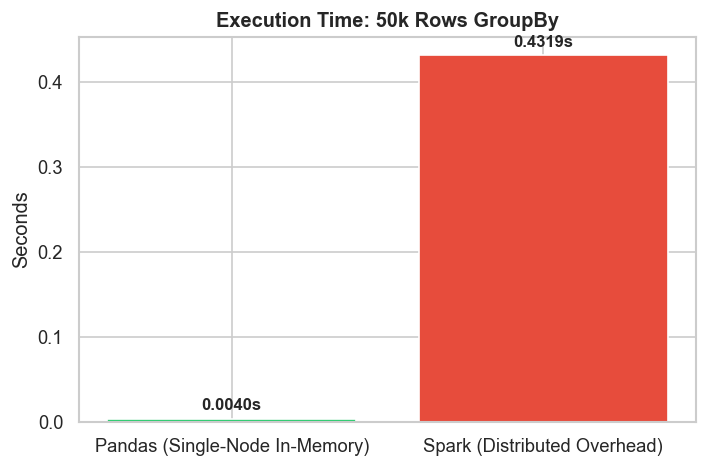

In [202]:
# benchmark groupBy execution time on the dataset
pandas_df = pd.read_parquet('../datasets/goto_transactions.parquet')

# -- pandas timing --
t0_pd = time.time()
_ = pandas_df.groupby('service_type')['amount'].sum()
t_pd = time.time() - t0_pd

# -- spark timing -- 
t0_sp = time.time()
# trigger action (collect) to measure full execution
_ = df_spark.groupBy('service_type').agg(sum('amount')).collect()
t_sp = time.time() - t0_sp

print(f"Pandas execution time: {t_pd:.4f} seconds")
print(f"Spark execution time:  {t_sp:.4f} seconds")

# note: For a 50k dataset, Pandas is expected to be faster due to lower overhead.
# Spark's advantage appears at scale (GBs/TBs) spanning multiple nodes.

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Pandas (Single-Node In-Memory)', 'Spark (Distributed Overhead)'], 
       [t_pd, t_sp], 
       color=['#2ECC71', '#E74C3C'], edgecolor='white')
ax.set_title('Execution Time: 50k Rows GroupBy', fontweight='bold')
ax.set_ylabel('Seconds')
for i, v in enumerate([t_pd, t_sp]):
    ax.text(i, v + 0.01, f"{v:.4f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [203]:
spark.stop()

---
<a id="soal_5_keamanan_lineage_monitoring"></a>
## Soal 5 — Keamanan, Lineage & Monitoring
---

In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
import random
from datetime import datetime, timedelta

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

<a id="51_access_control"></a>
### 5.1 Access Control
Simulasi kontrol akses berbasis peran untuk tiap zona Data Lake.

In [205]:
def check_access(role: str, zone: str) -> bool:
    """Simulate RBAC across data lake zones."""
    access_matrix = {
        'analyst':   ['trusted', 'refined'],
        'engineer':  ['raw', 'trusted', 'refined'],
        'admin':     ['raw', 'trusted', 'refined', 'transition'],
    }
    return zone in access_matrix.get(role, [])

print(f"Analyst -> RAW: {check_access('analyst', 'raw')}")
print(f"Engineer -> RAW: {check_access('engineer', 'raw')}")

Analyst -> RAW: False
Engineer -> RAW: True


--- Access Matrix ---


,transition,raw,trusted,refined
Role,,,,
analyst,False,False,True,True
engineer,False,True,True,True
admin,True,True,True,True


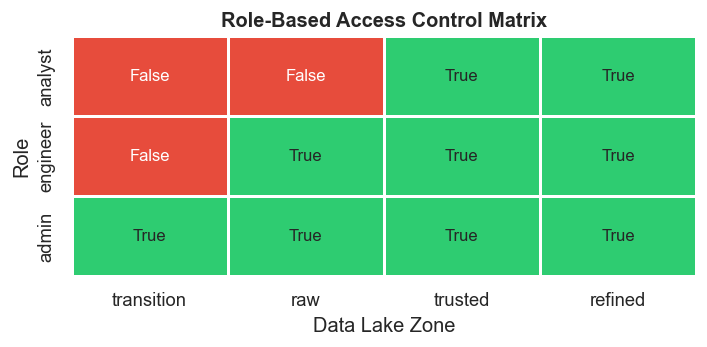

In [206]:
roles = ['analyst', 'engineer', 'admin']
zones = ['transition', 'raw', 'trusted', 'refined']

matrix_data = []
for r in roles:
    row = {z: check_access(r, z) for z in zones}
    row['Role'] = r
    matrix_data.append(row)

access_df = pd.DataFrame(matrix_data).set_index('Role')
print("--- Access Matrix ---")
display(access_df)

fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(access_df.astype(int), annot=access_df.astype(str), cmap=['#E74C3C', '#2ECC71'], 
            cbar=False, linewidths=1.5, linecolor='white', fmt='', ax=ax)
ax.set_title('Role-Based Access Control Matrix', fontweight='bold')
ax.set_xlabel('Data Lake Zone')
plt.tight_layout()
plt.show()

<a id="52_data_masking"></a>
### 5.2 Data Masking
Masking user_id dan merchant_id di Refined Zone menggunakan SHA-256.

In [207]:
df = pd.read_parquet('../datasets/goto_transactions.parquet')

def mask_id(val) -> str:
    """One-way cryptographic hash to mask identifying numbers."""
    return hashlib.sha256(str(val).encode()).hexdigest()[:12]

df_masked = df.copy()
df_masked['user_id_masked'] = df_masked['user_id'].apply(mask_id)
df_masked['merchant_id_masked'] = df_masked['merchant_id'].apply(mask_id)

print("--- Original vs Masked Sample (first 10 rows) ---")
display(df_masked[['user_id', 'user_id_masked', 'merchant_id', 'merchant_id_masked']].head(10))

# verify that different IDs produce different masks (collision resistance check)
unique_users_original = df['user_id'].nunique()
unique_users_masked = df_masked['user_id_masked'].nunique()
print(f"\nUnique original user_ids: {unique_users_original}")
print(f"Unique masked user_ids:   {unique_users_masked}")
assert unique_users_original == unique_users_masked, "Hash collision detected limit was too short!"
print("Masking verified: 1:1 consistent mapping without collision.")

--- Original vs Masked Sample (first 10 rows) ---


,user_id,user_id_masked,merchant_id,merchant_id_masked
0,71190,79e7faf41f99,113,6c658ee83fb7
1,42212,69f2b52b37eb,618,ee377871c736
2,79676,d6bc94671977,14926,764b895a8670
3,15559,5c609de312d5,13375,e0aceb930999
4,66298,a713f96ef8c8,16504,791ffd3e9cc6
5,93250,21444fffc45a,16625,4ca1cd4e7932
6,3380,375fc19c529c,16142,8d0b9a84ba45
7,43262,ad60cc6a584c,14406,985de91989a5
8,4088,3d4ba0dbe63a,12734,70bcb04fe555
9,78834,3607e501e297,7463,af1e1eb19b43



Unique original user_ids: 39239
Unique masked user_ids:   39239
Masking verified: 1:1 consistent mapping without collision.


<a id="53_data_lineage"></a>
### 5.3 Data Lineage
Pelacakan transformasi data dari RAW hingga Refined.

In [208]:
import json

# Step 1: RAW
raw_data = df.copy()
lineage = {
    'job_id': 'batch_202401',
    'source': 'goto_transactions.parquet',
    'zone': 'raw',
    'record_count': len(raw_data),
    'timestamp': datetime.now().isoformat(),
    'operations': []
}
lineage['operations'].append({'stage': 'RAW', 'action': 'Ingest from source', 'rows': len(raw_data)})

# Step 2: Trusted — dedup + validation
trusted_data = raw_data.drop_duplicates(subset=['event_id'])
trusted_data = trusted_data[trusted_data['amount'] > 0]
lineage['zone'] = 'trusted'
lineage['record_count'] = len(trusted_data)
lineage['operations'].append({
    'stage': 'Trusted', 
    'action': 'Deduplication & Schema Validation', 
    'rows_dropped': len(raw_data) - len(trusted_data),
    'rows_remaining': len(trusted_data)
})

# Step 3: Refined — aggregate by service_type
refined_data = trusted_data.groupby('service_type').agg(total_sum=('amount', 'sum')).reset_index()
lineage['zone'] = 'refined'
lineage['record_count'] = len(refined_data)
lineage['operations'].append({
    'stage': 'Refined', 
    'action': 'Aggregate daily metrics by service_type',
    'rows_aggregated': len(trusted_data),
    'output_rows': len(refined_data)
})

print("--- Final Lineage Metadata ---")
print(json.dumps(lineage, indent=2))

--- Final Lineage Metadata ---
{
  "job_id": "batch_202401",
  "source": "goto_transactions.parquet",
  "zone": "refined",
  "record_count": 5,
  "timestamp": "2026-04-10T04:26:04.576415",
  "operations": [
    {
      "stage": "RAW",
      "action": "Ingest from source",
      "rows": 50000
    },
    {
      "stage": "Trusted",
      "action": "Deduplication & Schema Validation",
      "rows_dropped": 0,
      "rows_remaining": 50000
    },
    {
      "stage": "Refined",
      "action": "Aggregate daily metrics by service_type",
      "rows_aggregated": 50000,
      "output_rows": 5
    }
  ]
}


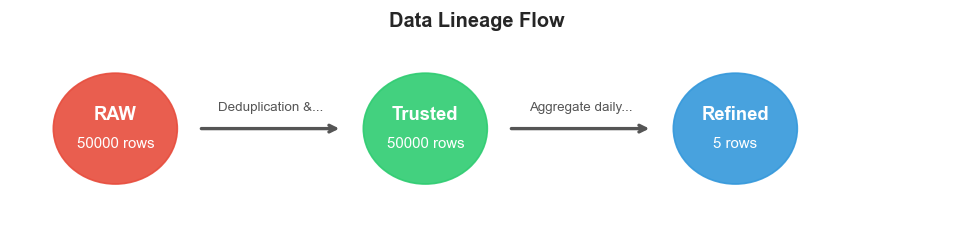

In [209]:
# visualize lineage flow
fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('off')

nodes = ['RAW', 'Trusted', 'Refined']
counts = [f"{lineage['operations'][0]['rows']} rows",
          f"{lineage['operations'][1]['rows_remaining']} rows",
          f"{lineage['operations'][2]['output_rows']} rows"]
colors = ['#E74C3C', '#2ECC71', '#3498DB']

for i, (node, count, color) in enumerate(zip(nodes, counts, colors)):
    circle = plt.Circle((i*3, 0), 0.6, color=color, alpha=0.9)
    ax.add_patch(circle)
    ax.text(i*3, 0.1, node, ha='center', fontweight='bold', color='white', fontsize=11)
    ax.text(i*3, -0.2, count, ha='center', color='white', fontsize=9)
    
    if i < 2:
        ax.annotate('', xy=(i*3 + 2.2, 0), xytext=(i*3 + 0.8, 0),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=2))
        ops_text = lineage['operations'][i+1]['action'][:15] + "..."
        ax.text(i*3 + 1.5, 0.2, ops_text, ha='center', fontsize=8, color='#555')

ax.set_xlim(-1, 8)
ax.set_ylim(-1, 1)
ax.set_title('Data Lineage Flow', fontweight='bold')
plt.show()

<a id="54_monitoring_metrics"></a>
### 5.4 Monitoring Metrics

<a id="job_failure_simulation"></a>
#### Job Failure Simulation
Simulasi 100 batch run dengan tingkat kegagalan 10%.

In [210]:
np.random.seed(42)
random.seed(42)

# Metric 1: Failure Rate Simulation (100 runs, 10% failure rate)
runs = 100
success_cum, fail_cum = [], []
s_cnt, f_cnt = 0, 0

for _ in range(runs):
    if random.random() > 0.1:
        s_cnt += 1
    else:
        f_cnt += 1
    success_cum.append(s_cnt)
    fail_cum.append(f_cnt)

<a id="latency_per_batch"></a>
#### Latency per Batch
Simulasi latensi pemrosesan per batch dengan threshold SLA.

In [211]:
# Metric 2: Batch Processing Latency
latency_data = [random.gauss(2.5, 0.8) for _ in range(30)]
sla_threshold = 3.5

<a id="storage_growth"></a>
#### Storage Growth
Proyeksi pertumbuhan storage historis selama 1 tahun.

In [212]:
# Metric 3: Storage Growth (50GB per day production volume)
days = 365
daily_gb = 50
storage_gb = [i * daily_gb * random.uniform(0.9, 1.1) for i in range(days)]

<a id="alert_rules"></a>
#### Alert Rules
Fungsi alert untuk validasi failure rate dan lonjakan outlier.

In [213]:
def alert_validation_failure_rate(failed_pct: float, threshold=0.05) -> str:
    """Raise alert if validation failure rate exceeds threshold."""
    return "Fail: Threshold Breached" if failed_pct >= threshold else "OK"

def alert_outlier_spike(outlier_count: int, baseline: float, multiplier=3) -> str:
    """Raise alert if outlier count exceeds multiplier * baseline."""
    return "Warning: Spike Detected" if outlier_count > (baseline * multiplier) else "OK"

alert_tests = [
    ('Failure Rate 8%', alert_validation_failure_rate(0.08)),
    ('Failure Rate 2%', alert_validation_failure_rate(0.02)),
    ('Outliers = 500 (Base=50)', alert_outlier_spike(500, 50, 3)),
    ('Outliers = 70 (Base=50)', alert_outlier_spike(70, 50, 3))
]

print("--- Alert Rule Tests ---")
for desc, status in alert_tests:
    print(f"{desc:<30} -> {status}")

--- Alert Rule Tests ---
Failure Rate 8%                -> Fail: Threshold Breached
Failure Rate 2%                -> OK
Outliers = 500 (Base=50)       -> Warning: Spike Detected
Outliers = 70 (Base=50)        -> OK


<a id="dashboard_monitoring"></a>
#### Dashboard Monitoring
Ringkasan 4 metrik monitoring dalam satu tampilan.

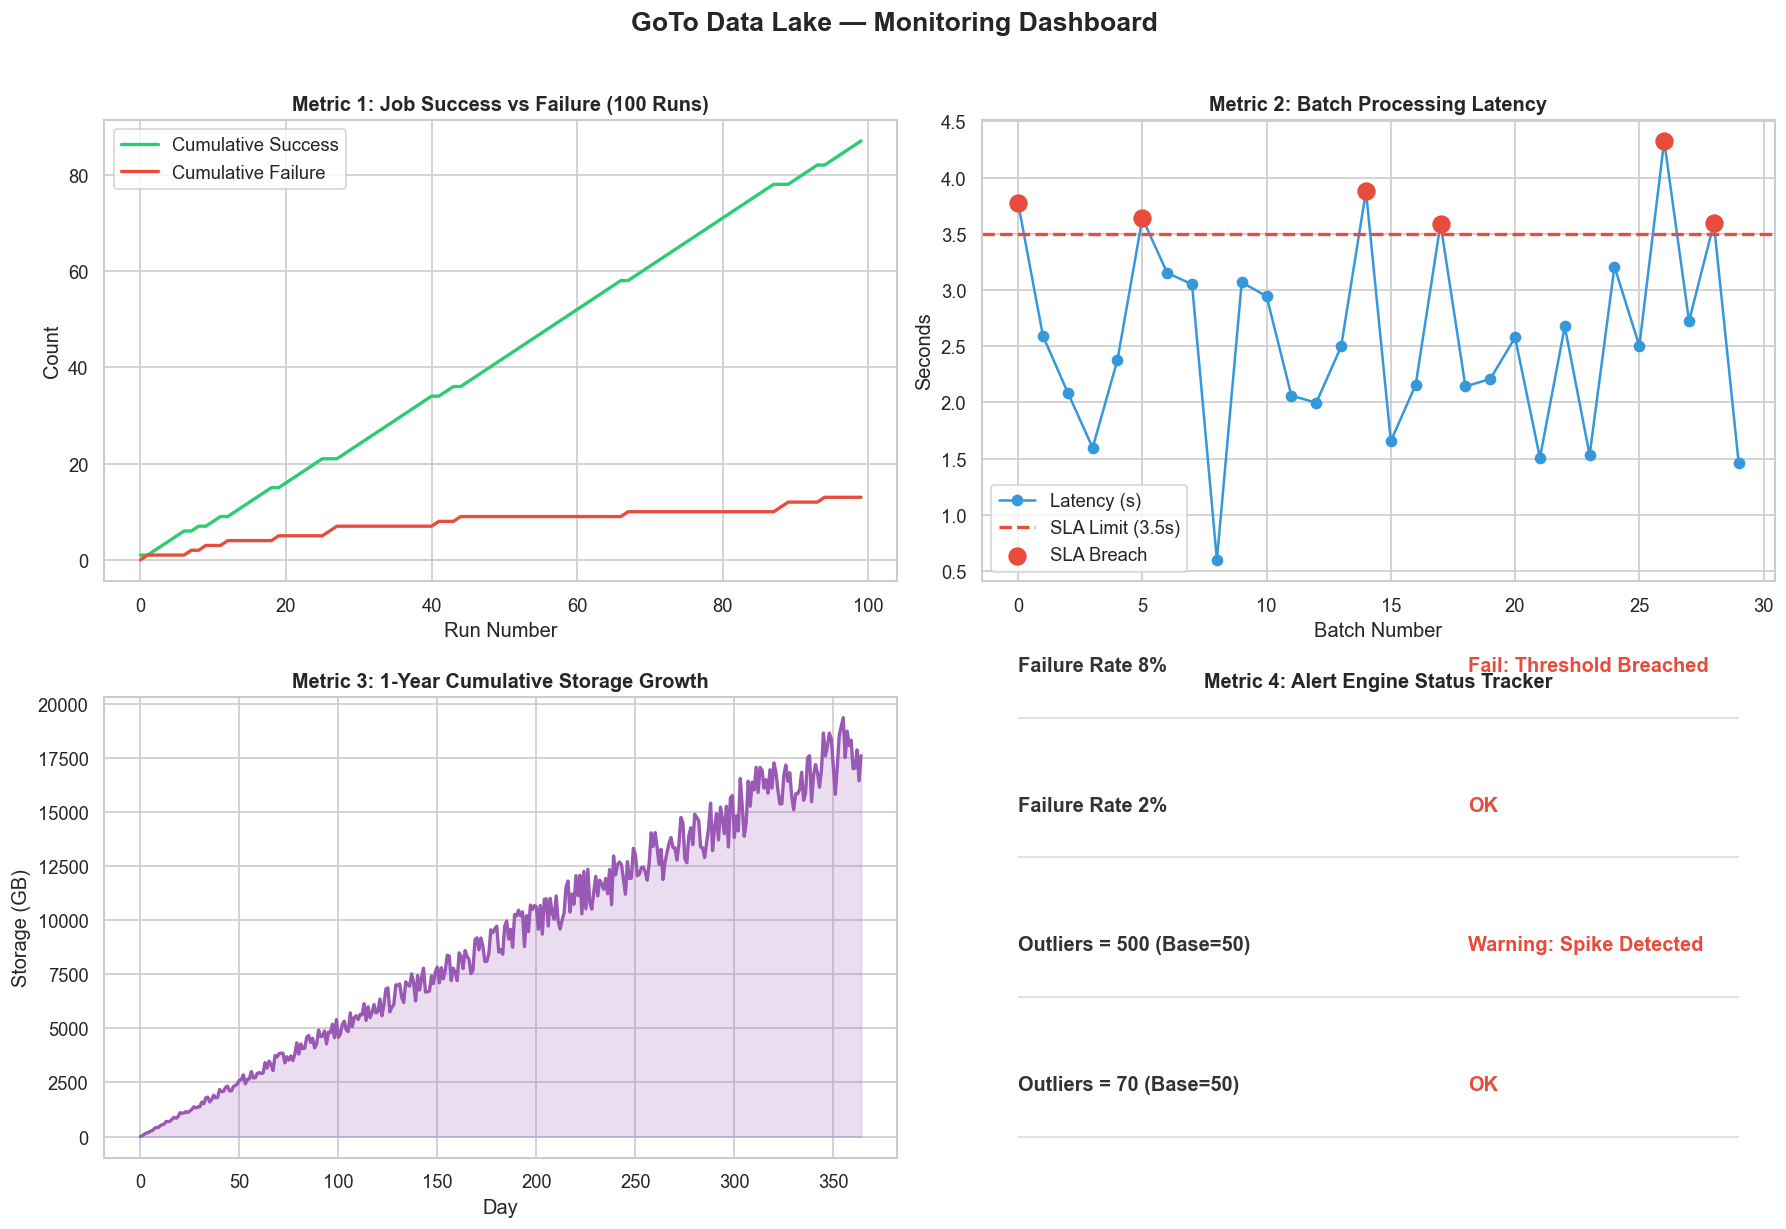

In [214]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Metric 1: Failure Rate
axes[0, 0].plot(range(runs), success_cum, label='Cumulative Success', color='#2ECC71', lw=2)
axes[0, 0].plot(range(runs), fail_cum, label='Cumulative Failure', color='#E74C3C', lw=2)
axes[0, 0].set_title('Metric 1: Job Success vs Failure (100 Runs)', fontweight='bold')
axes[0, 0].set_xlabel('Run Number')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()

# Metric 2: Latency
axes[0, 1].plot(range(30), latency_data, marker='o', color='#3498DB', label='Latency (s)', lw=1.5)
axes[0, 1].axhline(sla_threshold, color='#E74C3C', linestyle='--', label='SLA Limit (3.5s)', lw=2)
# highlight SLA breaches
breaches_x = [i for i, v in enumerate(latency_data) if v > sla_threshold]
breaches_y = [latency_data[i] for i in breaches_x]
axes[0, 1].scatter(breaches_x, breaches_y, color='#E74C3C', s=100, zorder=5, label='SLA Breach')
axes[0, 1].set_title('Metric 2: Batch Processing Latency', fontweight='bold')
axes[0, 1].set_xlabel('Batch Number')
axes[0, 1].set_ylabel('Seconds')
axes[0, 1].legend()

# Metric 3: Storage Growth
axes[1, 0].plot(range(days), storage_gb, color='#9B59B6', lw=2)
axes[1, 0].fill_between(range(days), storage_gb, alpha=0.2, color='#9B59B6')
axes[1, 0].set_title('Metric 3: 1-Year Cumulative Storage Growth', fontweight='bold')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Storage (GB)')

# Metric 4: Alert Summary
axes[1, 1].axis('off')
axes[1, 1].set_title('Metric 4: Alert Engine Status Tracker', fontweight='bold')

y_pos = 0.8
for desc, status in alert_tests:
    color = '#E74C3C' if '' in status else '#2ECC71'
    axes[1, 1].text(0.1, y_pos, desc, fontsize=12, fontweight='bold', color='#333')
    axes[1, 1].text(0.6, y_pos, status, fontsize=12, fontweight='bold', color=color)
    axes[1, 1].hlines(y_pos - 0.05, 0.1, 0.9, colors='#DDD', linestyles='solid', lw=1)
    y_pos -= 0.15

plt.suptitle('GoTo Data Lake — Monitoring Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()